In [1]:
# Projet Velib Paris - Analyse des données des stations de vélos en libre-service

In [2]:
# L'objectif de ce projet est d'analyser la répartition des velibs dans Paris.
# Nous allons dans un premier temps charger les données des stations de velibs, puis visualiser leur répartition géographique.

# Librairies


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import os
from geodatasets import get_path
from time import strftime, localtime
from threading import Timer
import osmnx as ox
import rasterio
import glob
from scipy.spatial import cKDTree
import networkx as nx
import seaborn as sns
import requests
import folium
import urllib.request
import branca.colormap as cm
#os.chdir(os.path.dirname(os.path.abspath("/Users/paulserre/Desktop/SciencesPo/Cours/velib/Velib.ipynb")))
os.chdir(os.path.dirname(os.path.abspath("/Users/paulemiletrancois/Documents/Master 1/Python/Velib/Velib.ipynb")))
from threading import Timer
from time import localtime, strftime
import contextily as ctx
from matplotlib.animation import FuncAnimation
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans

# Téléchargement des fichiers contenant nos données

## Un fichier = une journée avec les relevés heure par heure pour chaque station

In [4]:
# URLs des fichiers à télécharger
urls = [
 "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-11-13.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-11-14.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-11-15.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-11-16.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-11-17.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-11-18.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-11-19.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-11-20.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-11-21.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-11-22.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-11-23.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-11-24.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-11-25.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-11-26.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-11-27.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-11-28.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-11-29.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-11-30.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-12-01.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-12-02.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-12-03.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-12-04.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-12-05.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-12-06.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-12-07.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-12-08.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-12-09.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-12-10.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-12-11.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-12-12.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-12-13.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-12-14.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-12-15.csv",
    "https://raw.githubusercontent.com/paulserreku/velib/main/data/velib_data_2025-12-16.csv"
]


# Répertoire de destination
dest_dir = "/Users/paulemiletrancois/Documents/Master 1/Python/Velib"

# Créer le répertoire s'il n'existe pas
os.makedirs(dest_dir, exist_ok=True)

# Télécharger chaque fichier
for url in urls:
    filename = url.split('/')[-1]
    filepath = os.path.join(dest_dir, filename)
    
    print(f"Téléchargement de {filename}...")
    try:
        urllib.request.urlretrieve(url, filepath)
        print(f"✓ {filename} téléchargé avec succès")
    except Exception as e:
        print(f"✗ Erreur lors du téléchargement de {filename}: {e}")

print("\nTéléchargement terminé!")



Téléchargement de velib_data_2025-11-13.csv...
✓ velib_data_2025-11-13.csv téléchargé avec succès
Téléchargement de velib_data_2025-11-14.csv...
✓ velib_data_2025-11-14.csv téléchargé avec succès
Téléchargement de velib_data_2025-11-15.csv...
✓ velib_data_2025-11-15.csv téléchargé avec succès
Téléchargement de velib_data_2025-11-16.csv...
✓ velib_data_2025-11-16.csv téléchargé avec succès
Téléchargement de velib_data_2025-11-17.csv...
✓ velib_data_2025-11-17.csv téléchargé avec succès
Téléchargement de velib_data_2025-11-18.csv...
✓ velib_data_2025-11-18.csv téléchargé avec succès
Téléchargement de velib_data_2025-11-19.csv...
✓ velib_data_2025-11-19.csv téléchargé avec succès
Téléchargement de velib_data_2025-11-20.csv...
✓ velib_data_2025-11-20.csv téléchargé avec succès
Téléchargement de velib_data_2025-11-21.csv...
✓ velib_data_2025-11-21.csv téléchargé avec succès
Téléchargement de velib_data_2025-11-22.csv...
✓ velib_data_2025-11-22.csv téléchargé avec succès
Téléchargement de ve

# Data

In [5]:
files = ['velib_data_2025-11-13.csv', 'velib_data_2025-11-14.csv', 'velib_data_2025-11-15.csv',
         'velib_data_2025-11-16.csv', 'velib_data_2025-11-17.csv', 'velib_data_2025-11-18.csv',
         'velib_data_2025-11-19.csv', 'velib_data_2025-11-20.csv', 'velib_data_2025-11-21.csv',
         'velib_data_2025-11-22.csv', 'velib_data_2025-11-23.csv', 'velib_data_2025-11-24.csv',
         'velib_data_2025-11-25.csv', 'velib_data_2025-11-26.csv', 'velib_data_2025-11-27.csv',
         'velib_data_2025-11-28.csv', 'velib_data_2025-11-29.csv', 'velib_data_2025-11-30.csv',
         'velib_data_2025-12-01.csv', 'velib_data_2025-12-02.csv', 'velib_data_2025-12-03.csv',
         'velib_data_2025-12-04.csv', 'velib_data_2025-12-05.csv', 'velib_data_2025-12-06.csv',
         'velib_data_2025-12-07.csv', 'velib_data_2025-12-08.csv', 'velib_data_2025-12-09.csv',
         'velib_data_2025-12-10.csv', 'velib_data_2025-12-11.csv', 'velib_data_2025-12-12.csv',
         'velib_data_2025-12-13.csv', 'velib_data_2025-12-14.csv', 'velib_data_2025-12-15.csv',
         'velib_data_2025-12-16.csv']
dfs = []
for f in files:
    try:
        dfs.append(pd.read_csv(f, parse_dates=['Timer'], dayfirst=False))
        print(f"✓ {f} chargé ({len(dfs[-1])} lignes)")
    except Exception as e:
        print(f"✗ Erreur lecture {f}: {e}")

velib_location_df = pd.concat(dfs, ignore_index=True)
print(f"Total lignes concaténées: {len(velib_location_df)}")

# s'assurer que la colonne est une string et supprimer le crochet
s = velib_location_df['Coordonnees Geo'].astype(str).str.strip('[]')
velib_location_df['Coordonnees Geo'] = s

# On se débarrasse des lignes sans coordonnées valides
velib_location_df = velib_location_df[velib_location_df['Coordonnees Geo'].str.contains(',')]

# Séparer la colonne 'Location' en 'lat' et 'lon'
def getlatlong(x):
    return pd.Series([x.split(', ')[0], 
                      x.split(', ')[1]],
                      index = ["lat", "lon"])

velib_location_df = pd.concat((velib_location_df, velib_location_df['Coordonnees Geo'].apply(getlatlong)), axis=1)   

del velib_location_df['ID']

velib_location_df.head()


✓ velib_data_2025-11-13.csv chargé (13496 lignes)
✓ velib_data_2025-11-14.csv chargé (33000 lignes)
✓ velib_data_2025-11-15.csv chargé (33000 lignes)
✓ velib_data_2025-11-16.csv chargé (33000 lignes)
✓ velib_data_2025-11-17.csv chargé (33000 lignes)
✓ velib_data_2025-11-18.csv chargé (31500 lignes)
✓ velib_data_2025-11-19.csv chargé (33000 lignes)
✓ velib_data_2025-11-20.csv chargé (32997 lignes)
✓ velib_data_2025-11-21.csv chargé (31500 lignes)
✓ velib_data_2025-11-22.csv chargé (33000 lignes)
✓ velib_data_2025-11-23.csv chargé (33000 lignes)
✓ velib_data_2025-11-24.csv chargé (33000 lignes)
✓ velib_data_2025-11-25.csv chargé (33000 lignes)
✓ velib_data_2025-11-26.csv chargé (33000 lignes)
✓ velib_data_2025-11-27.csv chargé (33000 lignes)
✓ velib_data_2025-11-28.csv chargé (33000 lignes)
✓ velib_data_2025-11-29.csv chargé (33000 lignes)
✓ velib_data_2025-11-30.csv chargé (30000 lignes)
✓ velib_data_2025-12-01.csv chargé (31500 lignes)
✓ velib_data_2025-12-02.csv chargé (33000 lignes)


,Timer,Station,Code Station,Ebikes,Mechanical Bikes,Bikes Available,Docks Available,Capacity,Coordonnees Geo,lat,lon
0,2025-11-13 15:25:29,Benjamin Godard - Victor Hugo,16107.0,4.0,2.0,6,28,35.0,"48.865983, 2.275725",48.865983,2.275725
1,2025-11-13 15:25:29,Hôpital Mondor,40001.0,11.0,5.0,16,12,28.0,"48.798922410229, 2.4537451531298",48.798922410229,2.4537451531298
2,2025-11-13 15:25:29,Charonne - Robert et Sonia Delaunay,11104.0,3.0,2.0,5,15,20.0,"48.855907555969, 2.3925706744194",48.855907555969,2.3925706744194
3,2025-11-13 15:25:29,Messine - Place Du Pérou,8026.0,4.0,5.0,9,3,12.0,"48.875448033960744, 2.315508019010038",48.875448033960744,2.315508019010038
4,2025-11-13 15:25:29,Pierre et Marie Curie - Maurice Thorez,42016.0,2.0,2.0,4,22,27.0,"48.81580226360801, 2.376804985105991",48.81580226360801,2.376804985105991


In [6]:
velib_location_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1079780 entries, 0 to 1090484
Data columns (total 11 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   Timer             1079780 non-null  datetime64[ns]
 1   Station           1079780 non-null  object        
 2   Code Station      1079780 non-null  float64       
 3   Ebikes            1079780 non-null  float64       
 4   Mechanical Bikes  1079780 non-null  float64       
 5   Bikes Available   1079780 non-null  int64         
 6   Docks Available   1079780 non-null  int64         
 7   Capacity          1079780 non-null  float64       
 8   Coordonnees Geo   1079780 non-null  object        
 9   lat               1079780 non-null  object        
 10  lon               1079780 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(2), object(4)
memory usage: 98.9+ MB


In [7]:
velib_location_df.tail()


,Timer,Station,Code Station,Ebikes,Mechanical Bikes,Bikes Available,Docks Available,Capacity,Coordonnees Geo,lat,lon
1090480,2025-12-16 23:24:38,Saint-Antoine Sévigné,4010.0,15.0,6.0,21,2,26.0,"48.8550222, 2.3612322",48.8550222,2.3612322
1090481,2025-12-16 23:24:38,Bleuets - Bordières,40002.0,2.0,14.0,16,2,19.0,"48.802117531472, 2.4543687905029",48.802117531472,2.4543687905029
1090482,2025-12-16 23:24:38,Daumesnil - Picpus,12010.0,2.0,17.0,19,2,21.0,"48.8374688, 2.401765",48.8374688,2.401765
1090483,2025-12-16 23:24:38,Caumartin - Provence,9104.0,1.0,2.0,3,17,22.0,"48.874422773426545, 2.3284685611724854",48.874422773426545,2.3284685611724854
1090484,2025-12-16 23:24:38,Clichy - Place Blanche,18043.0,7.0,6.0,13,7,20.0,"48.883601088297, 2.3332237824798",48.883601088297,2.3332237824798


# Représentation des stations sur un Modèle Numérique de Terrain

In [8]:
# On importe le mask de la ville de Paris
MNT_Paris=np.loadtxt('MNT_Paris_25m.asc', skiprows=6)


In [9]:
# Convertir les colonnes lat et lon en float
velib_location_df['lat'] = velib_location_df['lat'].astype(float)
velib_location_df['lon'] = velib_location_df['lon'].astype(float)
velib_location_df.dtypes

Timer               datetime64[ns]
Station                     object
Code Station               float64
Ebikes                     float64
Mechanical Bikes           float64
Bikes Available              int64
Docks Available              int64
Capacity                   float64
Coordonnees Geo             object
lat                        float64
lon                        float64
dtype: object

In [10]:

#  Créer une colonne 'geometry' avec des objets Point
geometry = [Point(xy) for xy in zip(velib_location_df['lon'], velib_location_df['lat'])]
velib_gdf = gpd.GeoDataFrame(velib_location_df, geometry=geometry)
velib_gdf.head()

,Timer,Station,Code Station,Ebikes,Mechanical Bikes,Bikes Available,Docks Available,Capacity,Coordonnees Geo,lat,lon,geometry
0,2025-11-13 15:25:29,Benjamin Godard - Victor Hugo,16107.0,4.0,2.0,6,28,35.0,"48.865983, 2.275725",48.865983,2.275725,POINT (2.27572 48.86598)
1,2025-11-13 15:25:29,Hôpital Mondor,40001.0,11.0,5.0,16,12,28.0,"48.798922410229, 2.4537451531298",48.798922,2.453745,POINT (2.45375 48.79892)
2,2025-11-13 15:25:29,Charonne - Robert et Sonia Delaunay,11104.0,3.0,2.0,5,15,20.0,"48.855907555969, 2.3925706744194",48.855908,2.392571,POINT (2.39257 48.85591)
3,2025-11-13 15:25:29,Messine - Place Du Pérou,8026.0,4.0,5.0,9,3,12.0,"48.875448033960744, 2.315508019010038",48.875448,2.315508,POINT (2.31551 48.87545)
4,2025-11-13 15:25:29,Pierre et Marie Curie - Maurice Thorez,42016.0,2.0,2.0,4,22,27.0,"48.81580226360801, 2.376804985105991",48.815802,2.376805,POINT (2.3768 48.8158)


In [11]:
# afficher les colonnes de velib_gdf
print(velib_gdf.columns)

Index(['Timer', 'Station', 'Code Station', 'Ebikes', 'Mechanical Bikes',
       'Bikes Available', 'Docks Available', 'Capacity', 'Coordonnees Geo',
       'lat', 'lon', 'geometry'],
      dtype='object')


<AxesSubplot:>

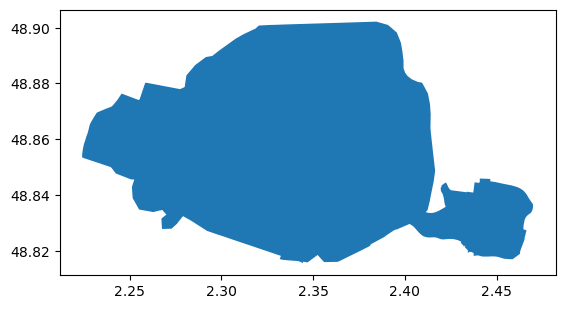

In [12]:
# Charger le polygone administratif de Paris
paris = ox.geocode_to_gdf("Paris, France")

# Afficher la carte
paris.plot()

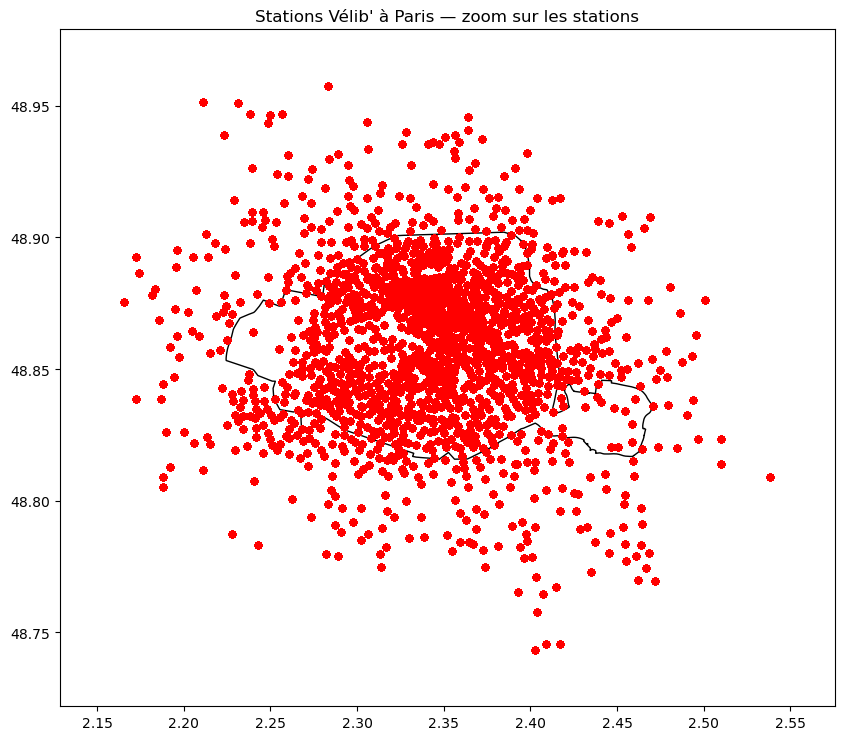

In [13]:
# On s'assure que les CRS sont corrects (velib en WGS84 lat/lon)
if velib_gdf.crs is None:
    velib_gdf = velib_gdf.set_crs(epsg=4326)

# Projecter vers le CRS de la couche 'paris'
velib_proj = velib_gdf.to_crs(paris.crs)

# Calculer les limites des stations et ajouter une marge (10%)
minx, miny, maxx, maxy = velib_proj.total_bounds
dx = maxx - minx
dy = maxy - miny
pad_x = dx * 0.1 if dx > 0 else 0.0001
pad_y = dy * 0.1 if dy > 0 else 0.0001

fig, ax = plt.subplots(figsize=(10,10))
paris.plot(ax=ax, color='white', edgecolor='black')
velib_proj.plot(ax=ax, marker='o', color='red', markersize=20)
ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)
ax.set_title("Stations Vélib' à Paris — zoom sur les stations")
plt.show()

In [14]:
# Lire le fichier MNT
MNT_Paris = np.loadtxt('MNT_Paris_25m.asc', skiprows=6)


print(np.shape(MNT_Paris))
MNT_Paris[0:5,0:5]

ncols = 800
nrows = 504
xllcenter = 642000
yllcenter = 6856000
cellsize = 25

MNT_Paris[MNT_Paris==-99999]=np.nan

xmin=xllcenter
ymin=yllcenter
xmax=xmin+ncols*cellsize
ymax=ymin+nrows*cellsize
cadre_p=[xmin, xmax, ymin, ymax]
print(cadre_p)


(504, 800)
[642000, 662000, 6856000, 6868600]


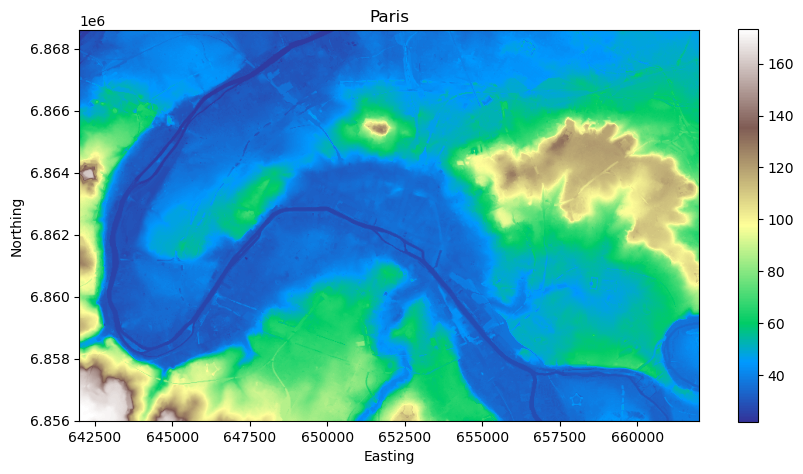

In [15]:
plt.figure(figsize=(10,6))

plt.imshow(MNT_Paris, cmap='terrain', extent=cadre_p)

plt.colorbar(shrink=0.85)

plt.title('Paris')
plt.xlabel('Easting')
plt.ylabel('Northing')


plt.show()

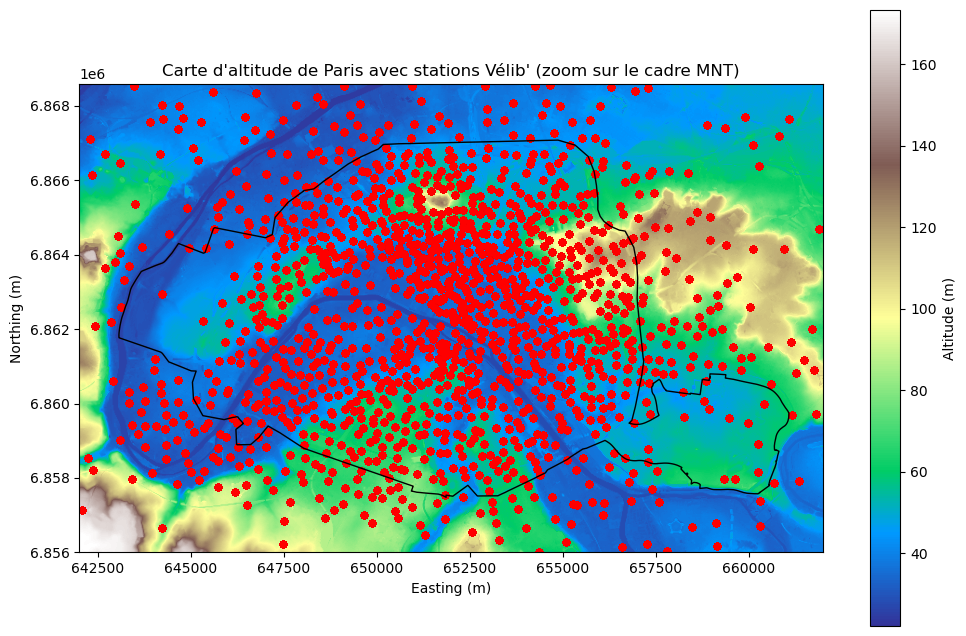

In [16]:
# --- Lire le MNT ---
MNT_Paris = np.loadtxt('MNT_Paris_25m.asc', skiprows=6)
MNT_Paris[MNT_Paris == -99999] = np.nan

# Paramètres du raster
ncols = 800
nrows = 504
xllcenter = 642000
yllcenter = 6856000
cellsize = 25

xmin = xllcenter
ymin = yllcenter
xmax = xmin + ncols * cellsize
ymax = ymin + nrows * cellsize

cadre_p = [xmin, xmax, ymin, ymax]

# --- Vérification et projection des stations Vélib ---
if velib_gdf.crs is None:
    velib_gdf = velib_gdf.set_crs(epsg=4326)  # WGS84

# Projecter vers le CRS du MNT (Lambert-93 / EPSG:2154)
velib_proj = velib_gdf.to_crs(epsg=2154)
paris_proj = paris.to_crs(epsg=2154)

# --- Filtrer les stations dans le cadre du MNT ---
velib_in_frame = velib_proj.cx[xmin:xmax, ymin:ymax]

# --- Tracer la figure ---
fig, ax = plt.subplots(figsize=(12,10))

# Carte d'altitude avec le même cadre exact
im = ax.imshow(MNT_Paris, cmap='terrain', extent=cadre_p, origin='upper')

# Limites de Paris
paris_proj.boundary.plot(ax=ax, edgecolor='black', linewidth=1)

# Stations Vélib dans le cadre
velib_in_frame.plot(ax=ax, marker='o', color='red', markersize=20, alpha=0.8)

# Barre de couleur
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Altitude (m)')

# Titres et axes
ax.set_title("Carte d'altitude de Paris avec stations Vélib' (zoom sur le cadre MNT)")
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')

plt.show()

# Distribution des altitudes

In [17]:
# Nous voulons maintenant obtenir l'altitude de chaque station de velib à partir du MNT.
# Pour cela, nous allons utiliser l'interpolation bilinéaire.
from scipy.interpolate import RegularGridInterpolator
# Créer les grilles de coordonnées x et y
x = np.linspace(xmin + cellsize / 2, xmax - cellsize / 2, ncols)
y = np.linspace(ymin + cellsize / 2, ymax - cellsize / 2, nrows)
interpolator = RegularGridInterpolator((y, x), MNT_Paris, bounds_error=False, fill_value=np.nan)
# Extraire les coordonnées des stations Vélib projetées
velib_coords = np.array([(point.y, point.x) for point in velib_proj.geometry])
# Interpoler les altitudes
velib_altitudes = interpolator(velib_coords)
# Ajouter les altitudes au GeoDataFrame
velib_gdf['altitude_m'] = velib_altitudes
velib_gdf.head()


,Timer,Station,Code Station,Ebikes,Mechanical Bikes,Bikes Available,Docks Available,Capacity,Coordonnees Geo,lat,lon,geometry,altitude_m
0,2025-11-13 15:25:29,Benjamin Godard - Victor Hugo,16107.0,4.0,2.0,6,28,35.0,"48.865983, 2.275725",48.865983,2.275725,POINT (2.27572 48.86598),30.141733
1,2025-11-13 15:25:29,Hôpital Mondor,40001.0,11.0,5.0,16,12,28.0,"48.798922410229, 2.4537451531298",48.798922,2.453745,POINT (2.45375 48.79892),NaN
2,2025-11-13 15:25:29,Charonne - Robert et Sonia Delaunay,11104.0,3.0,2.0,5,15,20.0,"48.855907555969, 2.3925706744194",48.855908,2.392571,POINT (2.39257 48.85591),85.734704
3,2025-11-13 15:25:29,Messine - Place Du Pérou,8026.0,4.0,5.0,9,3,12.0,"48.875448033960744, 2.315508019010038",48.875448,2.315508,POINT (2.31551 48.87545),49.838693
4,2025-11-13 15:25:29,Pierre et Marie Curie - Maurice Thorez,42016.0,2.0,2.0,4,22,27.0,"48.81580226360801, 2.376804985105991",48.815802,2.376805,POINT (2.3768 48.8158),43.537703


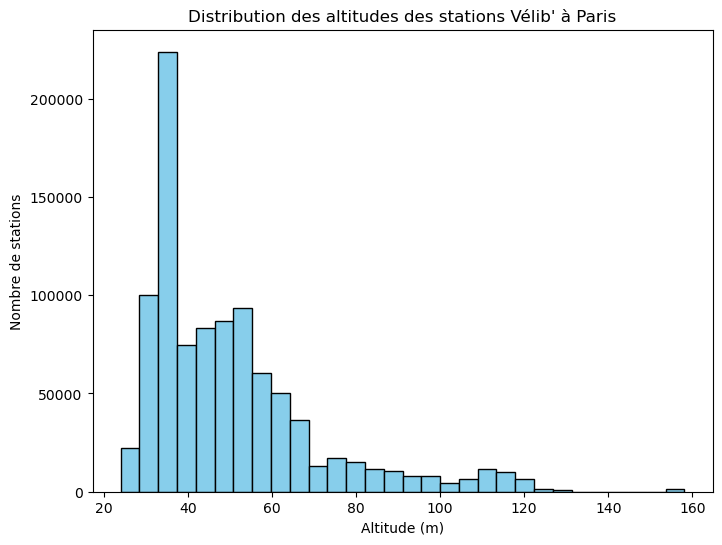

In [18]:
# Nous avons maintenant une visualisation claire des stations Vélib' par rapport à l'altitude dans Paris.
# Nous pouvons également analyser la distribution des altitudes des stations.
plt.figure(figsize=(8,6))
plt.hist(velib_gdf['altitude_m'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution des altitudes des stations Vélib' à Paris")
plt.xlabel("Altitude (m)")
plt.ylabel("Nombre de stations")
plt.show()


In [19]:
# Continuons les statistiques descriptives sur les altitudes des stations Vélib'.
mean_altitude = velib_gdf['altitude_m'].mean()
median_altitude = velib_gdf['altitude_m'].median()
std_altitude = velib_gdf['altitude_m'].std()
print(f"Altitude moyenne des stations Vélib': {mean_altitude:.2f} m")
print(f"Altitude médiane des stations Vélib': {median_altitude:.2f} m")
print(f"Écart-type des altitudes des stations Vélib': {std_altitude:.2f} m")

Altitude moyenne des stations Vélib': 50.17 m
Altitude médiane des stations Vélib': 44.85 m
Écart-type des altitudes des stations Vélib': 20.48 m


# Prédictions Modèle ARIMA pour une station (Caumartin-Provence)

In [34]:
# --- 1. Préparation des données ---
# Conversion en datetime
velib_gdf['Timer'] = pd.to_datetime(velib_gdf['Timer'], errors='coerce')

# Filtrer la station
station_9104 = velib_gdf[velib_gdf['Code Station'] == 9104].copy()

# CORRECTION CRITIQUE 1 : Rééchantillonnage (Resampling)
# ARIMA a besoin de pas de temps fixes. On lisse les données par heure (1H).
# On prend la dernière valeur connue de l'heure ou la moyenne.
station_9104 = station_9104.set_index('Timer')
# On remplit les trous éventuels avec interpolate ou ffill
ts_data = station_9104['Bikes Available'].resample('1h').mean().interpolate()

In [35]:
# --- 2. Différenciation (Stationnarisation) ---
# On utilise pandas diff() pour garder l'index temporel (les dates)
ts_diff = ts_data.diff().dropna()

In [37]:
# --- 3. Split Train / Test ---
split_point = int(0.9 * len(ts_diff))
train = ts_diff.iloc[:split_point]
test = ts_diff.iloc[split_point:]

print(f"Train size: {len(train)}, Test size: {len(test)}")

Train size: 720, Test size: 80


In [38]:
# --- 4. Modélisation ---
# CORRECTION 2 : On entraîne UNIQUEMENT sur 'train'
# Note : MA(55) est très élevé (cela regarde 55h en arrière). 
# J'ai réduit l'ordre pour l'exemple, mais vous pouvez le réaugmenter si justifié par l'ACF.
model = ARIMA(train, order=(1, 0, 12)) 
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:        Bikes Available   No. Observations:                  720
Model:                ARIMA(1, 0, 12)   Log Likelihood               -1943.875
Date:                Wed, 17 Dec 2025   AIC                           3917.749
Time:                        13:36:42   BIC                           3986.438
Sample:                    11-13-2025   HQIC                          3944.267
                         - 12-13-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0007      0.004     -0.162      0.871      -0.009       0.008
ar.L1         -0.0335      1.776     -0.019      0.985      -3.515       3.448
ma.L1         -0.2558      1.773     -0.144      0.8

In [43]:
# --- 5. Prédictions sur l'ensemble de test ---
# On prédit à partir de la fin du train jusqu'à la fin du test
start = len(train)
end = len(train) + len(test) - 1
predictions_diff = model_fit.predict(start=start, end=end, typ='levels')

# Assigner l'index temporel correct aux prédictions
predictions_diff.index = test.index

In [44]:
# --- 6. Reconstitution (Inverse Difference) ---
# Pour avoir le VRAI nombre de vélos, il faut rajouter la différence à la valeur précédente.
# On prend la dernière valeur réelle connue du train set comme point de départ.
last_real_value = ts_data.iloc[split_point - 1] 

# On fait une somme cumulée des variations prédites
predictions_reelles = last_real_value + predictions_diff.cumsum()

# Les vraies valeurs pour comparaison
real_values_test = ts_data.iloc[split_point:]

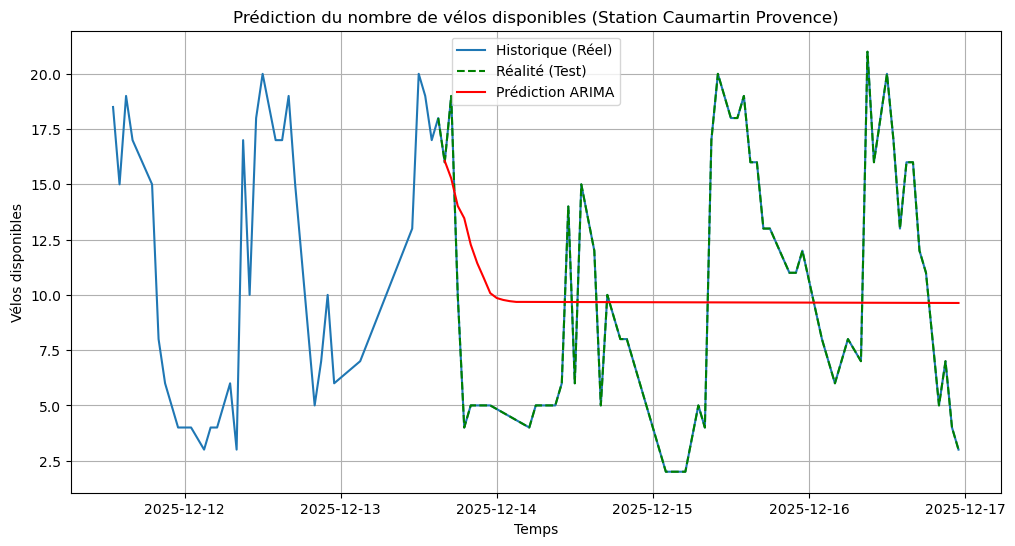

In [66]:
# --- 7. Visualisation ---
plt.figure(figsize=(12, 6))

# On affiche la fin du train et le test pour mieux voir
plt.plot(ts_data.iloc[split_point-50:], label='Historique (Réel)')
plt.plot(real_values_test.index, real_values_test, label='Réalité (Test)', color='green', linestyle='--')
plt.plot(predictions_reelles.index, predictions_reelles, label='Prédiction ARIMA', color='red')

plt.title('Prédiction du nombre de vélos disponibles (Station Caumartin Provence)')
plt.xlabel('Temps')
plt.ylabel('Vélos disponibles')
plt.legend()
plt.grid(True)
plt.show()

# Conclusion : ARMIA ne fonctionne pas, il faut utiliser SARIMA

In [68]:
# --- ÉTAPE 1 : Préparation et Nettoyage des Données ---
# On convertit la colonne temps en format datetime compréhensible par Pandas
velib_gdf['Timer'] = pd.to_datetime(velib_gdf['Timer'], errors='coerce')

# On filtre pour ne garder que la station qui nous intéresse
station_9104 = velib_gdf[velib_gdf['Code Station'] == 9104].copy()

# IMPORTANT : On définit le temps comme l'index du tableau
station_9104 = station_9104.set_index('Timer')

# CRUCIAL : Rééchantillonnage (Resampling)
# Vos données sont irrégulières (15h25, 16h29...).
# On force une grille régulière d'une heure ('1h') en faisant la moyenne des valeurs.
# .interpolate() permet de boucher les trous s'il manque une heure.
ts_data = station_9104['Bikes Available'].resample('1h').mean().interpolate()

In [69]:
# --- ÉTAPE 2 : Séparation Train / Test ---
# On garde 90% pour apprendre, et on teste sur les 10% restants (le futur)
split_point = int(0.9 * len(ts_data))
train = ts_data.iloc[:split_point]
test = ts_data.iloc[split_point:]

print(f"Données d'entraînement : {len(train)} heures")
print(f"Données de test : {len(test)} heures")

Données d'entraînement : 720 heures
Données de test : 81 heures


In [70]:
# --- ÉTAPE 3 : Configuration du Modèle SARIMA ---
# order=(p, d, q) -> Paramètres non-saisonniers (tendance immédiate)
# seasonal_order=(P, D, Q, s) -> Paramètres saisonniers (le cycle)

# order=(1, 0, 1) : On regarde juste l'heure d'avant.
# seasonal_order=(1, 1, 1, 24) :
#   - P=1, Q=1 : On regarde la corrélation avec la veille.
#   - D=1 : On soustrait la journée d'hier pour voir l'évolution nette (différenciation saisonnière).
#   - s=24 : Le cycle est de 24 heures.

model = ARIMA(train, order=(1, 0, 1), seasonal_order=(1, 1, 0, 24))

In [71]:
# --- ÉTAPE 4 : Entraînement ---
print("Entraînement du modèle en cours... (cela peut prendre quelques secondes)")
model_fit = model.fit()
print(model_fit.summary())

Entraînement du modèle en cours... (cela peut prendre quelques secondes)
                                     SARIMAX Results                                     
Dep. Variable:                   Bikes Available   No. Observations:                  720
Model:             ARIMA(1, 0, 1)x(1, 1, [], 24)   Log Likelihood               -1947.277
Date:                           Wed, 17 Dec 2025   AIC                           3902.555
Time:                                   14:08:49   BIC                           3920.736
Sample:                               11-13-2025   HQIC                          3909.585
                                    - 12-13-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8527      0.023     37.802      

In [72]:
# --- ÉTAPE 5 : Prédiction ---
# On demande au modèle de prédire sur la période du jeu de test
start = len(train)
end = len(train) + len(test) - 1

# typ='levels' signifie qu'on veut la prédiction en nombre de vélos (pas la différence)
predictions = model_fit.predict(start=start, end=end)
predictions.index = test.index  # On remet les bonnes dates sur les prédictions

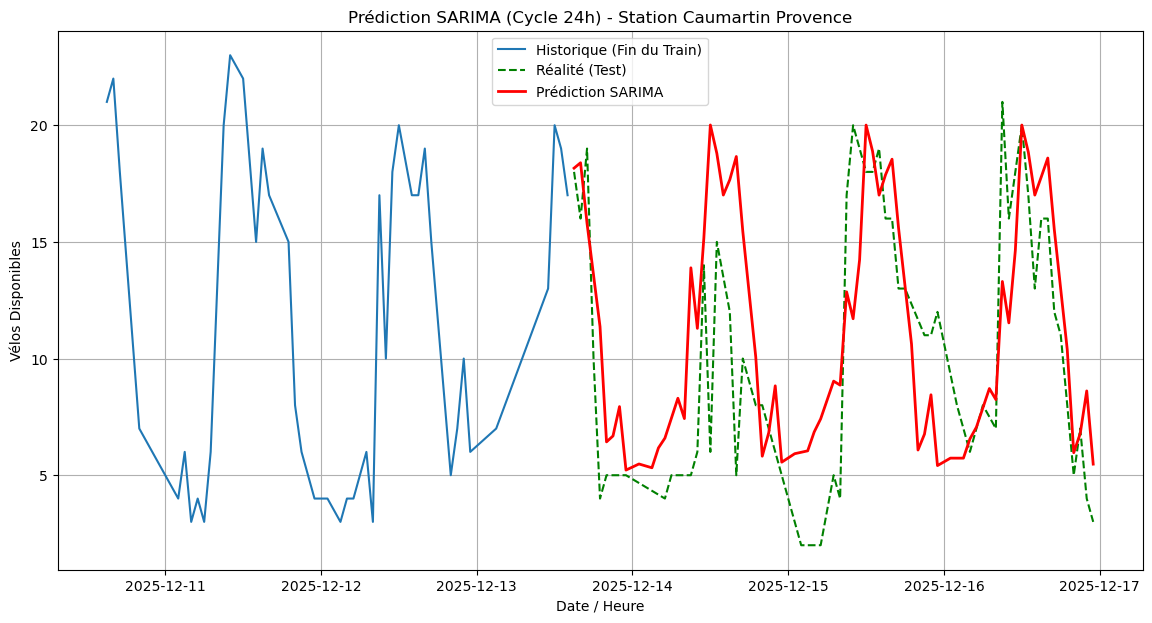

In [73]:
# --- ÉTAPE 6 : Visualisation ---
plt.figure(figsize=(14, 7))

# On affiche les 3 derniers jours du train pour voir la continuité
plt.plot(train.iloc[-72:], label='Historique (Fin du Train)')

# La réalité (ce qui s'est vraiment passé)
plt.plot(test, label='Réalité (Test)', color='green', linestyle='--')

# La prédiction SARIMA
plt.plot(predictions, label='Prédiction SARIMA', color='red', linewidth=2)

plt.title('Prédiction SARIMA (Cycle 24h) - Station Caumartin Provence')
plt.xlabel('Date / Heure')
plt.ylabel('Vélos Disponibles')
plt.legend()
plt.grid(True)
plt.show()

# Cartes

In [74]:
# Premières cartes

some_time = velib_gdf['Timer'][0]
some_data = velib_gdf[velib_gdf['Timer'] == some_time]
some_time = pd.to_datetime(some_time)
some_time

Timestamp('2025-11-13 15:25:29')

<AxesSubplot:>

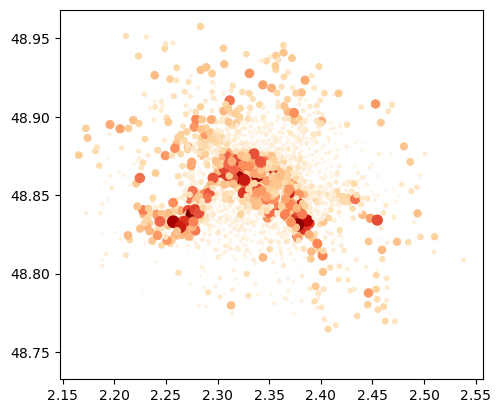

In [75]:
some_data.plot("Bikes Available", markersize="Bikes Available", cmap="OrRd")

KeyboardInterrupt: 

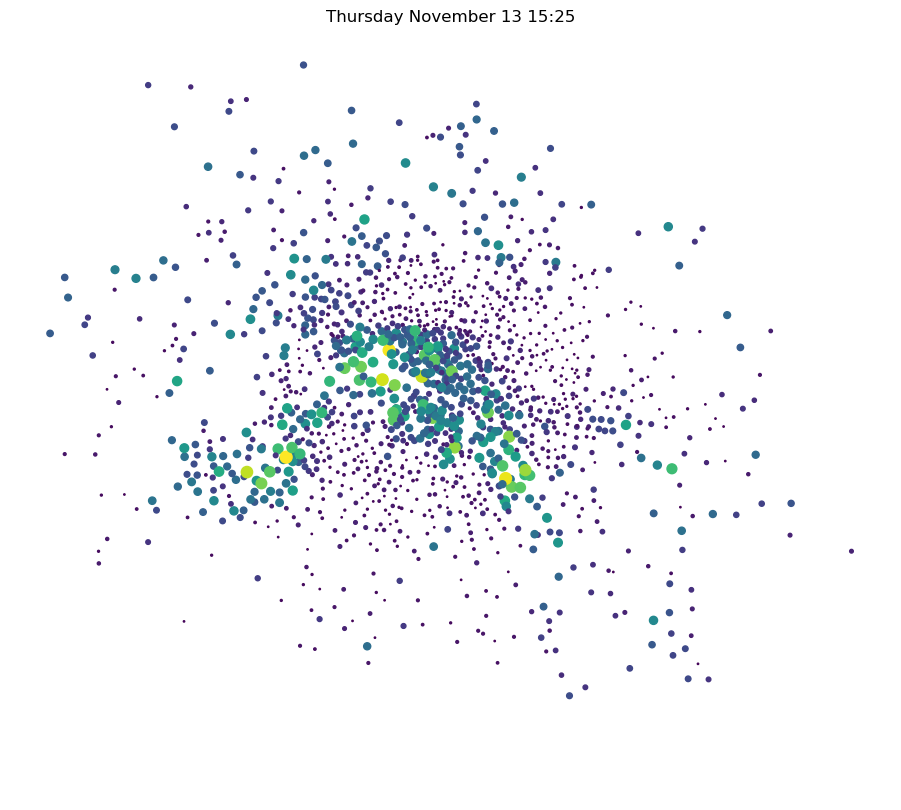

In [83]:
# Conversion des coordonnées
some_data = some_data.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 10))

ax.set_title(some_time.strftime("%A %B %d %H:%M"))
some_data.plot("Bikes Available", markersize="Bikes Available", cmap="viridis", ax=ax)
ax.set_axis_off()

# Ajout du fond de carte
ctx.add_basemap(ax)

plt.show()

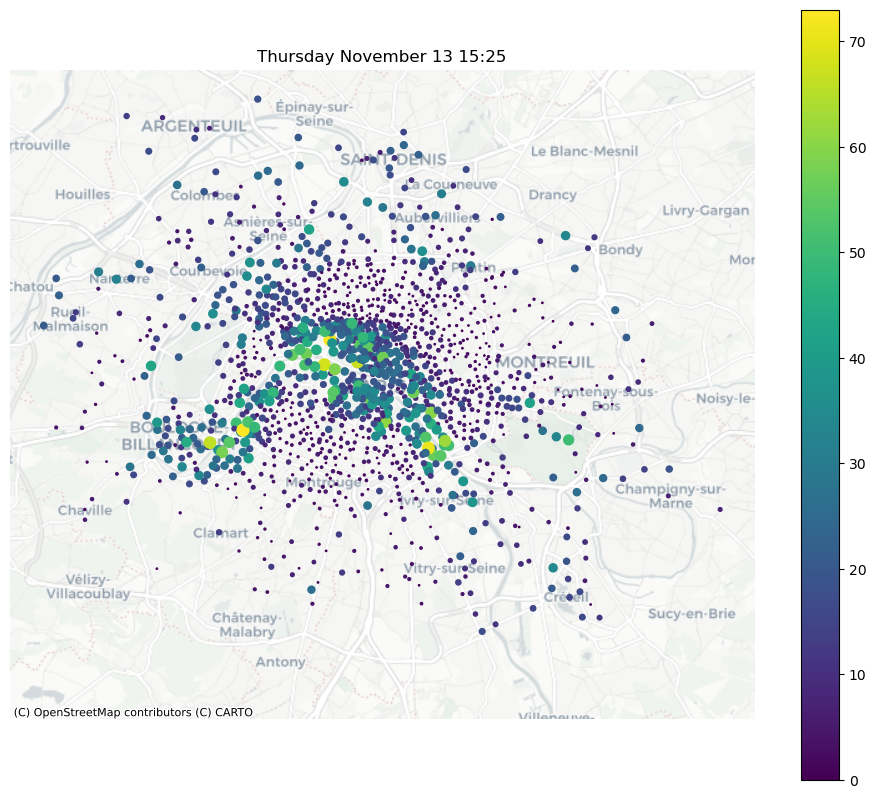

In [85]:
# Conversion des coordonnées
some_data = some_data.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 10))

ax.set_title(some_time.strftime("%A %B %d %H:%M"))

# Affichage
some_data.plot("Bikes Available", 
               markersize="Bikes Available", # Attention: vérifie que ce sont des nombres
               cmap="viridis", 
               ax=ax,
               legend=True) # J'ai ajouté la légende, c'est souvent utile

ax.set_axis_off()

# On spécifie 'source=...' pour éviter le serveur par défaut qui est en panne
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
# -----------------------------

plt.show()

In [86]:
paris_districts = gpd.read_file(
    "https://opendata.paris.fr/explore/dataset/quartier_paris/download?format=geojson&timezone=Europe/Berlin&lang=fr"
)
paris_districts = paris_districts.to_crs(epsg=3857)
paris_districts

Skipping field geom_x_y: unsupported OGR type: 3


,c_qu,c_quinsee,surface,n_sq_ar,c_ar,l_qu,st_area_shape,perimetre,st_perimeter_shape,n_sq_qu,geometry
0,46,7511202,7.205014e+06,750000012,12,Picpus,7.205014e+06,18261.910318,18260.602283,750000046,"POLYGON ((268419.092 6246007.058, 268497.144 6..."
1,19,7510503,7.036312e+05,750000005,5,Val-de-Grace,7.036312e+05,3485.831358,3485.614347,750000019,"POLYGON ((261098.113 6248614.355, 261223.852 6..."
2,47,7511203,1.902932e+06,750000012,12,Bercy,1.902932e+06,6155.005036,6154.591387,750000047,"POLYGON ((266180.603 6245407.688, 266082.325 6..."
3,32,7510804,1.182467e+06,750000008,8,Europe,1.182467e+06,4803.242769,4803.104033,750000032,"POLYGON ((257403.324 6253390.35, 257317.538 62..."
4,48,7511204,1.235916e+06,750000012,12,Quinze-Vingts,1.235916e+06,4509.486974,4509.226317,750000048,"POLYGON ((264183.946 6247852.678, 264095.921 6..."
...,...,...,...,...,...,...,...,...,...,...,...
75,45,7511201,5.970921e+06,750000012,12,Bel-Air,5.970921e+06,18427.822238,18426.599903,750000045,"POLYGON ((268711.851 6246668.986, 268726.083 6..."
76,50,7511302,3.044178e+06,750000013,13,Gare,3.044178e+06,7070.350567,7069.818894,750000050,"POLYGON ((263571.863 6243938.183, 263488.851 6..."
77,66,7511702,1.383508e+06,750000017,17,Plaine de Monceaux,1.383508e+06,5247.353247,5247.241240,750000066,"POLYGON ((256468.651 6256226.837, 256483.437 6..."
78,9,7510301,3.180877e+05,750000003,3,Arts-et-Métiers,3.180877e+05,2482.460453,2482.361077,750000009,"POLYGON ((262737.373 6252017.878, 262687.445 6..."


In [87]:
print(paris_districts.columns)

Index(['c_qu', 'c_quinsee', 'surface', 'n_sq_ar', 'c_ar', 'l_qu',
       'st_area_shape', 'perimetre', 'st_perimeter_shape', 'n_sq_qu',
       'geometry'],
      dtype='object')


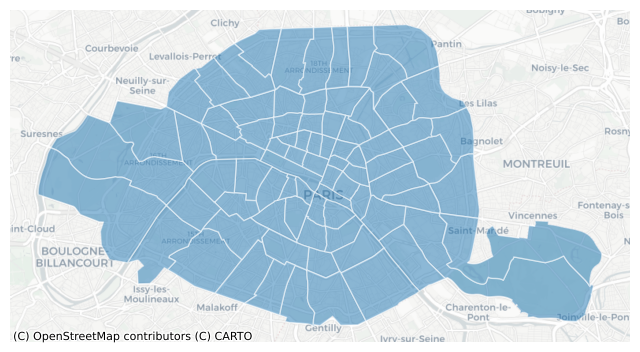

In [88]:
fig, ax = plt.subplots(figsize=(8, 6))

paris_districts.plot(ax=ax, alpha=0.5, edgecolor="white")
ax.set_axis_off()
ctx.add_basemap(ax,  source=ctx.providers.CartoDB.Positron)

plt.show()

In [89]:
#On crée une nouvelle colonne nommée velib_number, c'est à dire le nombre de vélibs présents dans le quartier.
#Pour ce faire, on somme tous les vélos qui sont inclus dans le quartier en question. Cette opération est rendue possible par la méthode .within() qui va déterminer si la station est bien localisée dans le polygone représentant le quartier.

paris_districts["velib_number"] = paris_districts.apply(
    lambda district: (
        some_data.within(district.geometry) * some_data["Bikes Available"]
    ).sum(),
    axis=1
)

In [90]:
# On peut faire la même opération pour calculer le nombre maximum de vélibs dans le quartier, et donc le pourcentage d'occupation des stations dans le quartier

paris_districts["max_velib_number"] = paris_districts.apply(
        lambda district: (
            some_data.within(district.geometry) * some_data["Capacity"]
        ).sum(),
        axis=1,
)

paris_districts["proportion"] = paris_districts["velib_number"] / paris_districts["max_velib_number"]

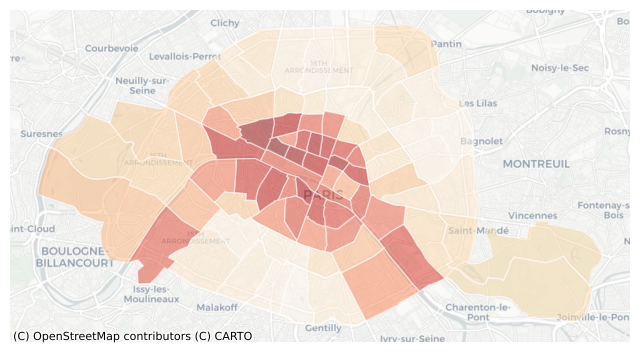

In [92]:
# on va tracer le taux d'occupation des stations Vélib, quartier par quartier

fig, ax = plt.subplots(figsize=(8, 6))

paris_districts.plot("proportion", cmap="OrRd", ax=ax, alpha=0.5, edgecolor="white")
ax.set_axis_off()
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

plt.show()

In [93]:
# Convertir en projection Web Mercator pour contextily
paris_districts = paris_districts.to_crs(epsg=3857)
velib_gdf = velib_gdf.to_crs(epsg=3857)

In [94]:
velib_gdf.head()

,Timer,Station,Code Station,Ebikes,Mechanical Bikes,Bikes Available,Docks Available,Capacity,Coordonnees Geo,lat,lon,geometry,altitude_m,Total_Bikes
0,2025-11-13 15:25:29,Benjamin Godard - Victor Hugo,16107.0,4.0,2.0,6,28,35.0,"48.865983, 2.275725",48.865983,2.275725,POINT (253332.548 6252152.031),30.141733,6.0
1,2025-11-13 15:25:29,Hôpital Mondor,40001.0,11.0,5.0,16,12,28.0,"48.798922410229, 2.4537451531298",48.798922,2.453745,POINT (273149.661 6240811.351),NaN,16.0
2,2025-11-13 15:25:29,Charonne - Robert et Sonia Delaunay,11104.0,3.0,2.0,5,15,20.0,"48.855907555969, 2.3925706744194",48.855908,2.392571,POINT (266339.749 6250447.194),85.734704,5.0
3,2025-11-13 15:25:29,Messine - Place Du Pérou,8026.0,4.0,5.0,9,3,12.0,"48.875448033960744, 2.315508019010038",48.875448,2.315508,POINT (257761.174 6253753.896),49.838693,9.0
4,2025-11-13 15:25:29,Pierre et Marie Curie - Maurice Thorez,42016.0,2.0,2.0,4,22,27.0,"48.81580226360801, 2.376804985105991",48.815802,2.376805,POINT (264584.721 6243664.49),43.537703,4.0


In [95]:
# Extraire l'heure de chaque observation
velib_gdf['Hour'] = velib_gdf['Timer'].dt.floor('h')

# Obtenir toutes les heures uniques, triées
hours = sorted(velib_gdf['Hour'].unique())

In [96]:
# Extraire l'arrondissement depuis le code station ou autre colonne
# Adapter selon votre structure de données
# Exemple: si c_ar existe déjà dans velib_gdf, sinon créer une jointure spatiale
velib_gdf = gpd.sjoin(velib_gdf, paris_districts[['c_ar', 'geometry']], 
                                  how='left', predicate='within')
# On supprime les lignes sans arrondissement (stations hors Paris)
velib_gdf = velib_gdf.dropna(subset=['c_ar'])
velib_gdf.head()

,Timer,Station,Code Station,Ebikes,Mechanical Bikes,Bikes Available,Docks Available,Capacity,Coordonnees Geo,lat,lon,geometry,altitude_m,Total_Bikes,Hour,index_right,c_ar
0,2025-11-13 15:25:29,Benjamin Godard - Victor Hugo,16107.0,4.0,2.0,6,28,35.0,"48.865983, 2.275725",48.865983,2.275725,POINT (253332.548 6252152.031),30.141733,6.0,2025-11-13 15:00:00,59.0,16.0
2,2025-11-13 15:25:29,Charonne - Robert et Sonia Delaunay,11104.0,3.0,2.0,5,15,20.0,"48.855907555969, 2.3925706744194",48.855908,2.392571,POINT (266339.749 6250447.194),85.734704,5.0,2025-11-13 15:00:00,56.0,11.0
3,2025-11-13 15:25:29,Messine - Place Du Pérou,8026.0,4.0,5.0,9,3,12.0,"48.875448033960744, 2.315508019010038",48.875448,2.315508,POINT (257761.174 6253753.896),49.838693,9.0,2025-11-13 15:00:00,3.0,8.0
7,2025-11-13 15:25:29,Guersant - Gouvion-Saint-Cyr,17041.0,4.0,13.0,17,14,36.0,"48.88287775178599, 2.287667370814871",48.882878,2.287667,POINT (254661.967 6255011.515),35.019291,17.0,2025-11-13 15:00:00,38.0,17.0
8,2025-11-13 15:25:29,Morillons - Dantzig,15047.0,2.0,1.0,3,49,52.0,"48.83310149953933, 2.299380004405976",48.833101,2.299380,POINT (255965.811 6246589.513),35.770282,3.0,2025-11-13 15:00:00,16.0,15.0


In [97]:
# Grouper par arrondissement et heure
grouped = velib_gdf.groupby(['Timer', 'c_ar']).agg({
    'Bikes Available': 'sum',
    'Capacity': 'sum'
}).reset_index()

In [98]:
grouped.head()

,Timer,c_ar,Bikes Available,Capacity
0,2025-11-13 15:25:29,1.0,673,775.0
1,2025-11-13 15:25:29,2.0,593,748.0
2,2025-11-13 15:25:29,3.0,366,456.0
3,2025-11-13 15:25:29,4.0,427,722.0
4,2025-11-13 15:25:29,5.0,870,1243.0


In [99]:

# Calculer le taux d'occupation
grouped['occupation'] = (grouped['Bikes Available'] / grouped['Capacity'] * 100).fillna(0)
grouped.head()

,Timer,c_ar,Bikes Available,Capacity,occupation
0,2025-11-13 15:25:29,1.0,673,775.0,86.838710
1,2025-11-13 15:25:29,2.0,593,748.0,79.278075
2,2025-11-13 15:25:29,3.0,366,456.0,80.263158
3,2025-11-13 15:25:29,4.0,427,722.0,59.141274
4,2025-11-13 15:25:29,5.0,870,1243.0,69.991955


In [100]:
# Obtenir les timestamps uniques triés
timestamps = sorted(grouped['Timer'].unique())
len(timestamps)

720

In [101]:
print(f"Données prêtes: {len(timestamps)} timestamps")
print(f"Colonnes grouped: {grouped.columns.tolist()}")
print(f"Colonnes paris_districts: {paris_districts.columns.tolist()}")

Données prêtes: 720 timestamps
Colonnes grouped: ['Timer', 'c_ar', 'Bikes Available', 'Capacity', 'occupation']
Colonnes paris_districts: ['c_qu', 'c_quinsee', 'surface', 'n_sq_ar', 'c_ar', 'l_qu', 'st_area_shape', 'perimetre', 'st_perimeter_shape', 'n_sq_qu', 'geometry', 'velib_number', 'max_velib_number', 'proportion']


In [102]:
def animate_districts(frame):
    ax.clear()
    current_time = timestamps[frame]
    
    # Filtrer les données pour ce timestamp
    current_data = grouped[grouped['Timer'] == current_time]
    
    # Fusionner avec les polygones des arrondissements
    paris_plot = paris_districts.merge(
        current_data[['c_ar', 'occupation']], 
        on='c_ar', 
        how='left'
    )
    #paris_plot['occupation'] = paris_plot['occupation'].fillna(0)
    
    # Tracer les arrondissements avec la couleur selon l'occupation
    paris_plot.plot(
        column='occupation',
        cmap=cmap,
        norm=norm,
        ax=ax,
        edgecolor='black',
        linewidth=0.5,
        legend=False
    )
    
    # Ajouter les labels des arrondissements
    for idx, row in paris_plot.iterrows():
        centroid = row.geometry.centroid
        ax.text(
            centroid.x, centroid.y, 
            str(int(row['c_ar'])) if pd.notna(row['c_ar']) else '',
            fontsize=8, ha='center', va='center',
            fontweight='bold'
        )
    
    # Titre avec date et heure
    ax.set_title(
        f"Taux d'occupation des Vélib par arrondissement\n{current_time.strftime('%A %d %B %Y - %H:%M')}",
        fontsize=16, fontweight='bold', pad=20
    )
    
    ax.set_axis_off()
    
    # Ajouter le fond de carte
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
    
    return ax

Animation créée avec succès!
Nombre de frames: 720
Période couverte: 2025-11-13 15:25:29 à 2025-12-16 23:24:38


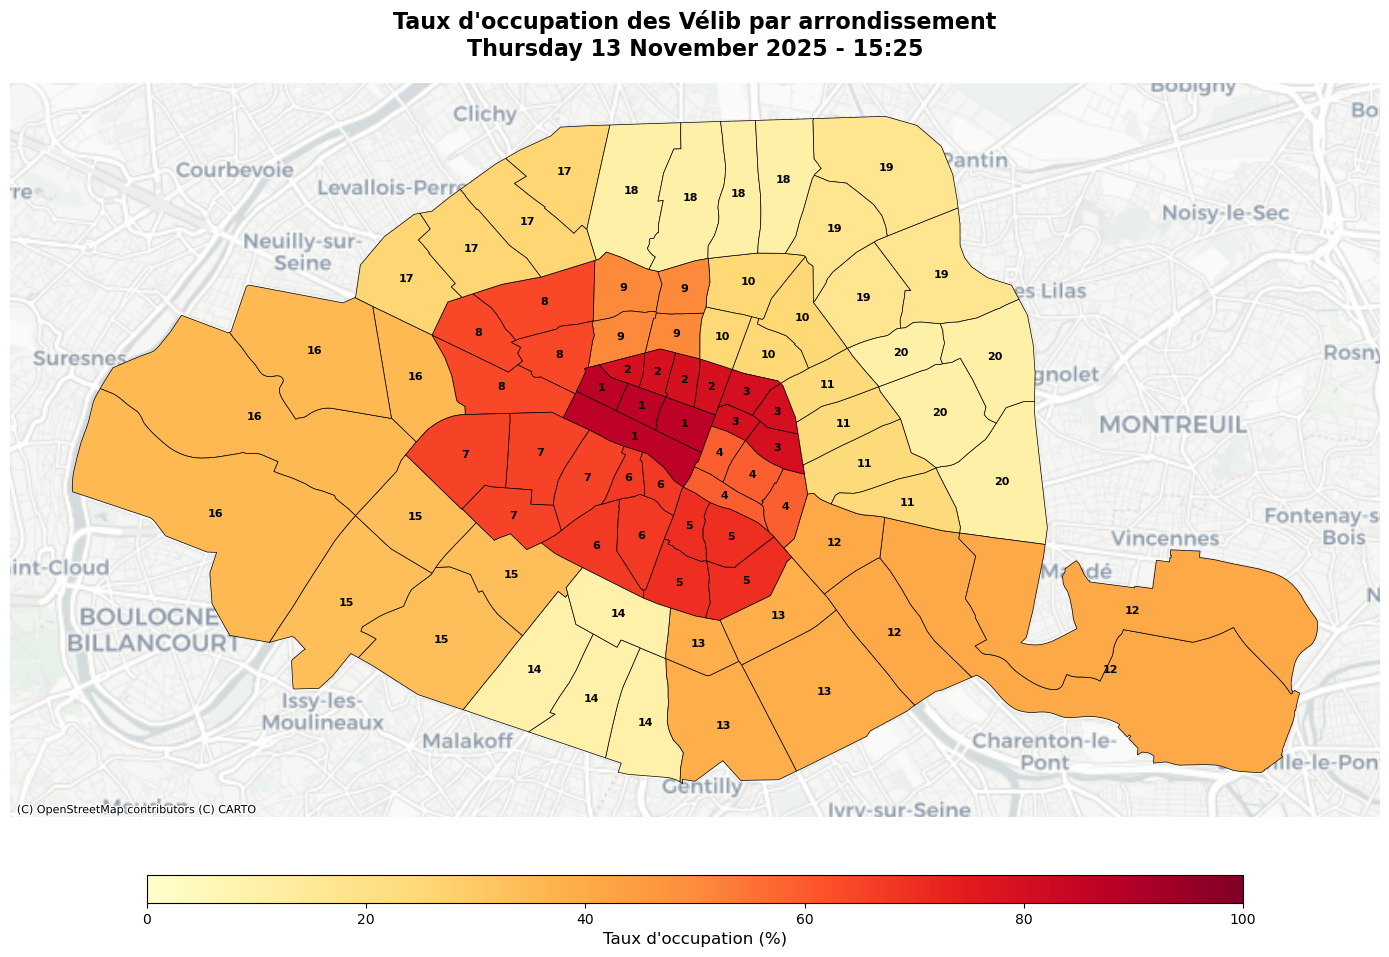

In [103]:
# Préparer la figure
fig, ax = plt.subplots(figsize=(14, 12))

# Configurer la colormap
cmap = plt.cm.YlOrRd
norm = Normalize(vmin=0, vmax=100)


# Créer l'animation
anim = FuncAnimation(
    fig, 
    animate_districts, 
    frames=len(timestamps),
    interval=200,  # 200ms entre chaque frame
    repeat=True
)

# Ajouter une colorbar fixe
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', 
                    pad=0.05, aspect=40, shrink=0.8)
cbar.set_label('Taux d\'occupation (%)', fontsize=12)

# Sauvegarder en HTML
anim.save('velib_animation_districts.html', writer='html', fps=5)

# Ou sauvegarder en MP4 (nécessite ffmpeg)
# anim.save('velib_animation.mp4', writer='ffmpeg', fps=5, dpi=150)

plt.tight_layout()
print("Animation créée avec succès!")
print(f"Nombre de frames: {len(timestamps)}")
print(f"Période couverte: {timestamps[0]} à {timestamps[-1]}")

# Series temporelles par quartier

In [110]:
# Jointure spatiale : on identifie le quartier de chaque observation
geo_districts = gpd.sjoin(paris_districts, velib_gdf, how="left", rsuffix="_velib")
# On aggrège les données par quartier en ne gardant que les premières 7 jours
geo_districts = geo_districts[geo_districts["Timer"] < geo_districts["Timer"].min() + pd.Timedelta(days=1)]
occupation_data = geo_districts.groupby(["l_qu", "Timer"], as_index=False).agg({"Bikes Available":"sum", "geometry": "first"})
occupation_data.head()

# On normalise l'occupation par le nombre maximum de vélos disponibles dans chaque quartier
max_bikes_per_district = occupation_data.groupby("l_qu")["Bikes Available"].max().reset_index()
max_bikes_per_district.rename(columns={"Bikes Available":"Max Bikes"}, inplace=True)
occupation_data = occupation_data.merge(max_bikes_per_district, on="l_qu")
occupation_data["Occupation Rate"] = occupation_data["Bikes Available"] / occupation_data["Max Bikes"] * 100
occupation_data.head()

,l_qu,Timer,Bikes Available,geometry,Max Bikes,Occupation Rate
0,Amérique,2025-11-13 15:25:29,48,"POLYGON ((268213.423 6254556.887, 268274.488 6...",198,24.242424
1,Amérique,2025-11-13 16:29:49,48,"POLYGON ((268213.423 6254556.887, 268274.488 6...",198,24.242424
2,Amérique,2025-11-13 17:23:05,64,"POLYGON ((268213.423 6254556.887, 268274.488 6...",198,32.323232
3,Amérique,2025-11-13 18:34:11,78,"POLYGON ((268213.423 6254556.887, 268274.488 6...",198,39.393939
4,Amérique,2025-11-13 19:19:09,73,"POLYGON ((268213.423 6254556.887, 268274.488 6...",198,36.868687


In [111]:
velib_gdf.columns

Index(['Timer', 'Station', 'Code Station', 'Ebikes', 'Mechanical Bikes',
       'Bikes Available', 'Docks Available', 'Capacity', 'Coordonnees Geo',
       'lat', 'lon', 'geometry', 'altitude_m', 'Total_Bikes', 'Hour',
       'index_right', 'c_ar'],
      dtype='object')

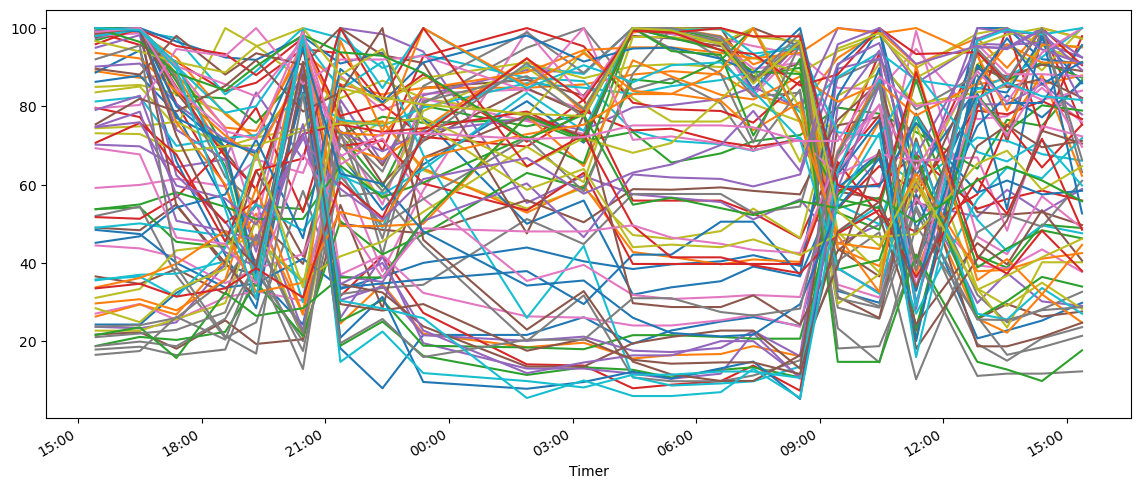

In [112]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14,6))

occupation_data.groupby('l_qu').plot(x="Timer", y="Occupation Rate", kind="line", ax=ax, legend=False)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.show()

# Clustering spatial

In [113]:
# Calculer le taux d'occupation
velib_gdf['occupation'] = (
    velib_gdf['Bikes Available'] / velib_gdf['Capacity']
) * 100

In [114]:
# Construire les features par station

features = velib_gdf.groupby('Code Station').agg(
    lat = ('lat', 'first'),
    lon = ('lon', 'first'),
    occupation_mean = ('occupation', 'mean'),
    occupation_std  = ('occupation', 'std'),
    pct_empty       = ('occupation', lambda x: (x == 0).mean() * 100),
    pct_full        = ('occupation', lambda x: (x == 100).mean() * 100),
    mean_capacity   = ('Capacity', 'mean'),
    mean_bikes      = ('Bikes Available', 'mean')
).reset_index()
features = features.dropna()


In [115]:
features.head()

,Code Station,lat,lon,occupation_mean,occupation_std,pct_empty,pct_full,mean_capacity,mean_bikes
0,1001.0,48.857059,2.341798,61.331699,26.418129,1.805556,4.444444,17.0,10.426389
1,1002.0,48.857993,2.346917,56.092172,29.678345,1.527778,3.055556,22.0,12.340278
2,1003.0,48.859059,2.347694,69.073676,30.333059,0.000000,3.501401,43.0,29.701681
3,1006.0,48.862630,2.349807,49.158249,21.181828,0.555556,0.000000,33.0,16.222222
4,1007.0,48.863589,2.347779,62.222222,25.678148,0.000000,2.083333,16.0,9.955556


In [116]:
# Standardiser les variables

X = features[['occupation_mean', 'occupation_std', 'pct_empty', 'pct_full', 'mean_capacity']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


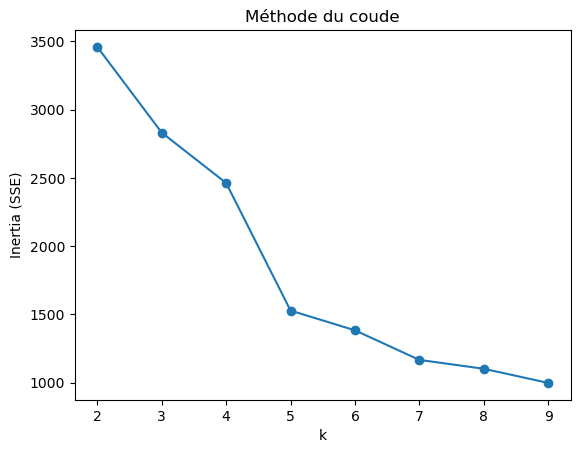

In [117]:
# Trouver le bon nombre de clusters avec la méthode du coude (le bon k)

inertia = []

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2,10), inertia, '-o')
plt.xlabel("k")
plt.ylabel("Inertia (SSE)")
plt.title("Méthode du coude")
plt.show()


In [118]:
# Clustering avec KMeans

k = 2
km = KMeans(n_clusters=k, random_state=42)
features['cluster'] = km.fit_predict(X_scaled)


In [119]:
# Analyse des clusters

features.groupby('cluster')[['occupation_mean','occupation_std','pct_empty','pct_full']].mean()

,occupation_mean,occupation_std,pct_empty,pct_full
cluster,,,,
0,54.869663,25.505347,0.808735,1.74608
1,22.126456,16.870337,7.300609,0.04196


<AxesSubplot:>

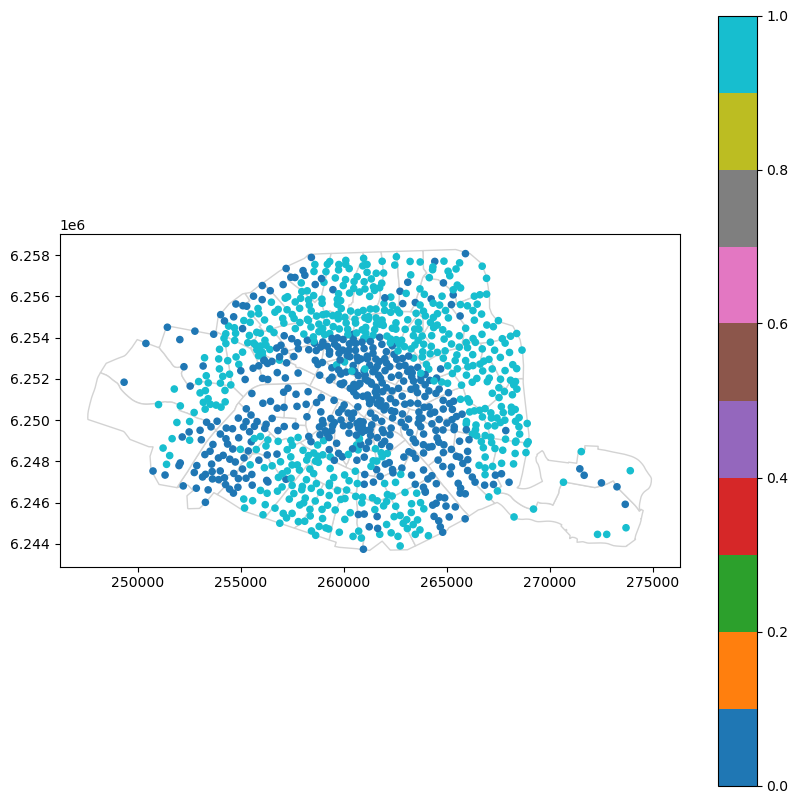

In [120]:
# Visualisation sur la carte

gdf = gpd.GeoDataFrame(
    features,
    geometry=gpd.points_from_xy(features['lon'], features['lat']),
    crs="EPSG:4326"
)

ax = paris_districts.to_crs(3857).plot(
    figsize=(10, 10), edgecolor="lightgray", facecolor="white"
)

gdf.to_crs(3857).plot(
    ax=ax,
    column='cluster',
    cmap='tab10',
    markersize=20,
    legend=True
)


# On trace les times series des deux groupes séparément

In [121]:
# On fusionne velib_gdf avec les clusters
velib_gdf = velib_gdf.merge(
    features[['Code Station', 'cluster']],
    on='Code Station',
    how='left'
)
velib_gdf.head()

,Timer,Station,Code Station,Ebikes,Mechanical Bikes,Bikes Available,Docks Available,Capacity,Coordonnees Geo,lat,lon,geometry,altitude_m,Total_Bikes,Hour,index_right,c_ar,occupation,cluster
0,2025-11-13 15:25:29,Benjamin Godard - Victor Hugo,16107.0,4.0,2.0,6,28,35.0,"48.865983, 2.275725",48.865983,2.275725,POINT (253332.548 6252152.031),30.141733,6.0,2025-11-13 15:00:00,59.0,16.0,17.142857,1.0
1,2025-11-13 15:25:29,Charonne - Robert et Sonia Delaunay,11104.0,3.0,2.0,5,15,20.0,"48.855907555969, 2.3925706744194",48.855908,2.392571,POINT (266339.749 6250447.194),85.734704,5.0,2025-11-13 15:00:00,56.0,11.0,25.000000,1.0
2,2025-11-13 15:25:29,Messine - Place Du Pérou,8026.0,4.0,5.0,9,3,12.0,"48.875448033960744, 2.315508019010038",48.875448,2.315508,POINT (257761.174 6253753.896),49.838693,9.0,2025-11-13 15:00:00,3.0,8.0,75.000000,0.0
3,2025-11-13 15:25:29,Guersant - Gouvion-Saint-Cyr,17041.0,4.0,13.0,17,14,36.0,"48.88287775178599, 2.287667370814871",48.882878,2.287667,POINT (254661.967 6255011.515),35.019291,17.0,2025-11-13 15:00:00,38.0,17.0,47.222222,0.0
4,2025-11-13 15:25:29,Morillons - Dantzig,15047.0,2.0,1.0,3,49,52.0,"48.83310149953933, 2.299380004405976",48.833101,2.299380,POINT (255965.811 6246589.513),35.770282,3.0,2025-11-13 15:00:00,16.0,15.0,5.769231,1.0


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


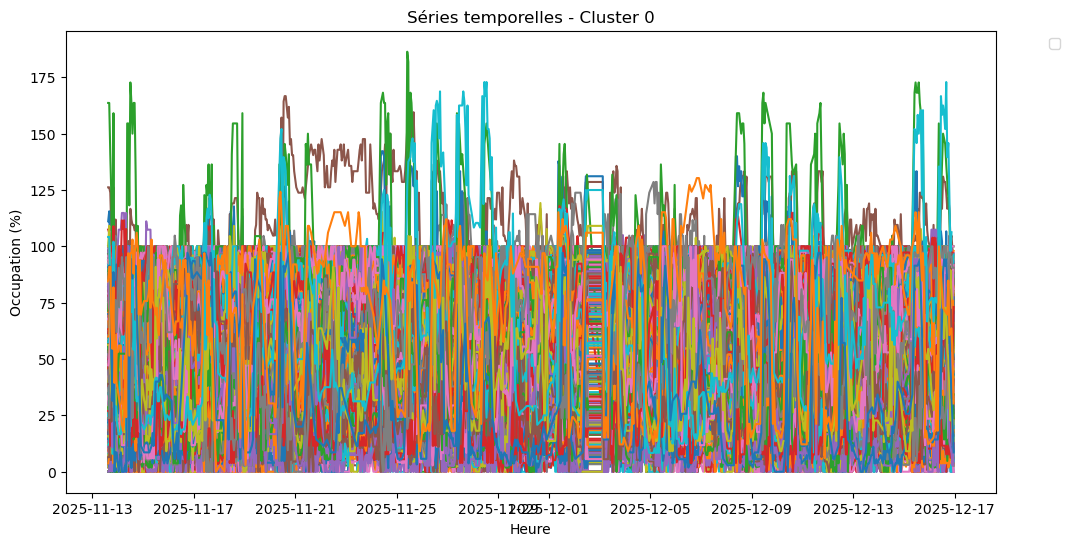

In [122]:
# Séies temporelles par station individuelle

# Exemple pour le cluster 1
cluster_0 = velib_gdf[velib_gdf['cluster'] == 0]
stations_0 = cluster_0['Station'].unique()

plt.figure(figsize=(12,6))
for station in stations_0:
    station_data = cluster_0[cluster_0['Station'] == station]
    plt.plot(station_data['Hour'], station_data['occupation'])

plt.title("Séries temporelles - Cluster 0")
plt.xlabel("Heure")
plt.ylabel("Occupation (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

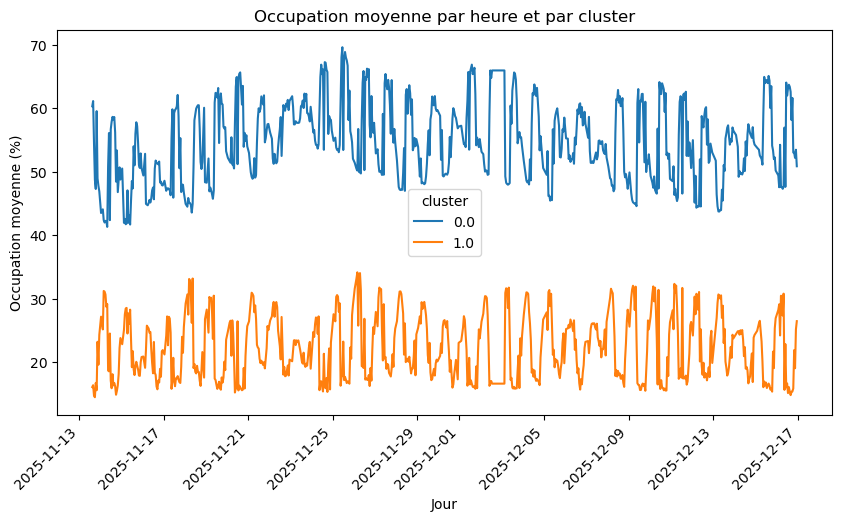

In [125]:
# Moyenne de l'occupation par heure pour chaque cluster
mean_occupation = velib_gdf.groupby(['cluster','Hour'])['occupation'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=mean_occupation, x='Hour', y='occupation', hue='cluster', palette='tab10')
plt.title("Occupation moyenne par heure et par cluster")
plt.xlabel("Jour")
plt.ylabel("Occupation moyenne (%)")
plt.xticks(rotation=45, ha='right')
plt.show()


# IMPACT DE L’ALTITUDE SUR L'OCCUPATION DES VÉLIBS


RÉSULTATS DU MODÈLE
           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: occupation   
No. Observations: 712388  Method:             REML         
No. Groups:       993     Scale:              471.9413     
Min. group size:  387     Log-Likelihood:     -3206372.7667
Max. group size:  720     Converged:          Yes          
Mean group size:  717.4                                    
-----------------------------------------------------------
              Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
-----------------------------------------------------------
Intercept     54.184    0.929  58.310 0.000  52.363  56.005
altitude_m     0.015    0.018   0.854 0.393  -0.020   0.051
cluster      -32.865    0.657 -50.024 0.000 -34.152 -31.577
Group Var    100.951    0.210                              


INTERPRÉTATION
- Coefficient altitude  : 0.0155
  Interprétation :
  > positif → stations plus hautes = plus remplies
  > négatif → stations plus ha

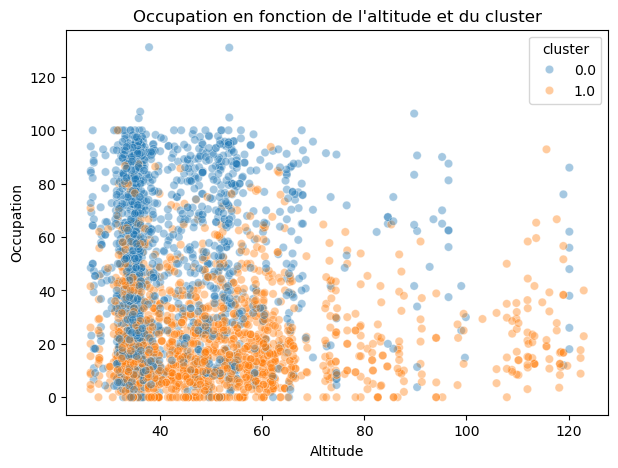


IMPORTANCE DES VARIABLES (Random Forest)
 - altitude_m : 0.276
 - cluster_1.0 : 0.724


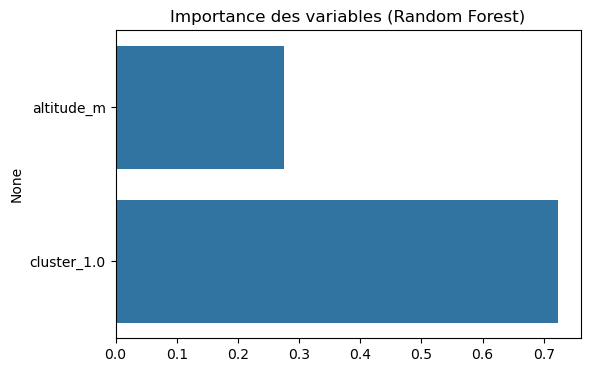


CONCLUSION
Ce code permet :
 - d’estimer correctement l’effet de l’altitude sur l’occupation,
 - de tenir compte du fait que chaque station est observée plusieurs fois,
 - d’évaluer l’importance relative des variables avec une méthode non linéaire.


In [127]:
# ==========================================================
# ANALYSE DE L’IMPACT DE L’ALTITUDE SUR L'OCCUPATION DES VÉLIBS
# ==========================================================

# ----------------------------------------------------------
# 1) Préparation des données
# ----------------------------------------------------------

# On garde uniquement les colonnes nécessaires
data = velib_gdf[['Code Station', 'cluster', 'altitude_m', 'occupation']].dropna()

# Vérification de stations avec trop peu d'observations
obs_count = data.groupby("Code Station").size()
stations_invalid = obs_count[obs_count < 2]

if len(stations_invalid) > 0:
    print(f"{len(stations_invalid)} stations retirées car moins de 2 observations.")
    data = data[data["Code Station"].isin(obs_count[obs_count >= 2].index)]

# ----------------------------------------------------------
# 2) Standardisation (important pour la convergence)
# ----------------------------------------------------------

data_scaled = data.copy()
scaler = StandardScaler()

# Standardisation des variables numériques
data_scaled[['altitude_m', 'occupation']] = scaler.fit_transform(
    data_scaled[['altitude_m', 'occupation']]
)

# ----------------------------------------------------------
# 3) Modèle mixte (effets aléatoires par station)
# ----------------------------------------------------------
# Méthode Nelder-Mead : plus stable et converge souvent mieux

model = smf.mixedlm(
    "occupation ~ altitude_m + cluster",
    data=data,
    groups=data["Code Station"]
).fit(method='nm', maxiter=500, disp=False)

print("\n====================")
print("RÉSULTATS DU MODÈLE")
print("====================")
print(model.summary())

# ----------------------------------------------------------
# 4) Interprétation simplifiée
# ----------------------------------------------------------

coef_alt = model.params.get("altitude_m")
coef_cluster = model.params.get("cluster")

print("\n====================")
print("INTERPRÉTATION")
print("====================")
print(f"- Coefficient altitude  : {coef_alt:.4f}")
print("  Interprétation :")
print("  > positif → stations plus hautes = plus remplies")
print("  > négatif → stations plus hautes = plus vides")

print(f"\n- Coefficient cluster : {coef_cluster:.4f}")
print("  > effet moyen du changement de cluster sur l’occupation")

print(f"\n- Variance station (effet aléatoire) :")
print(model.random_effects[list(model.random_effects.keys())[0]])

# ----------------------------------------------------------
# 5) Visualisation : occupation vs altitude
# ----------------------------------------------------------

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=data.sample(min(3000, len(data))),  # échantillon si dataset massifs
    x="altitude_m",
    y="occupation",
    hue="cluster",
    alpha=0.4
)
plt.title("Occupation en fonction de l'altitude et du cluster")
plt.xlabel("Altitude")
plt.ylabel("Occupation")
plt.show()

# ----------------------------------------------------------
# 6) Importance relative des variables (Random Forest)
# ----------------------------------------------------------

from sklearn.ensemble import RandomForestRegressor

print("\n====================")
print("IMPORTANCE DES VARIABLES (Random Forest)")
print("====================")

X = data[['altitude_m', 'cluster']]
y = data['occupation']

# Transformation du cluster en numérique
X = pd.get_dummies(X, columns=['cluster'], drop_first=True)

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X, y)

for name, imp in zip(X.columns, rf.feature_importances_):
    print(f" - {name} : {imp:.3f}")

plt.figure(figsize=(6,4))
sns.barplot(x=rf.feature_importances_, y=X.columns)
plt.title("Importance des variables (Random Forest)")
plt.show()

print("\n====================")
print("CONCLUSION")
print("====================")
print("Ce code permet :")
print(" - d’estimer correctement l’effet de l’altitude sur l’occupation,")
print(" - de tenir compte du fait que chaque station est observée plusieurs fois,")
print(" - d’évaluer l’importance relative des variables avec une méthode non linéaire.")


In [128]:
corr = velib_gdf["occupation"].corr(velib_gdf["altitude_m"])
print("Corrélation occupation-altitude :", corr)


Corrélation occupation-altitude : -0.11414000631420525


# Si on regarde uniquement la répartition de vélos ÉLECTRIQUES selon l'altitude et le cluster

In [ ]:
# ==========================================================
# Analyse du ratio Ebikes / Capacity en fonction de l'altitude et du cluster
# ==========================================================

# ----------------------------------------------------------
# Préparation des données
# ----------------------------------------------------------

# On garde uniquement les colonnes nécessaires
data = velib_gdf[['Code Station', 'cluster', 'altitude_m', 'Timer', 'Ebikes', 'Mechanical Bikes', 'Capacity']].dropna()


# Calcul du ratio ebikes / Capacity
data = data[data['Capacity'] > 0]  # éviter division par zéro
data['ratio_ebikes'] = data['Ebikes'] / data['Capacity']

In [ ]:
# ----------------------------------------------------------
# Modèle mixte (effets aléatoires par station)
# ----------------------------------------------------------
# Méthode Nelder-Mead pour la convergence
model = smf.mixedlm(
    "ratio_ebikes ~ altitude_m + cluster",
    data=data,
    groups=data["Code Station"]
).fit(method='nm', maxiter=500, disp=False)

print("\n====================")
print("RÉSULTATS DU MODÈLE MIXTE")
print("====================")
print(model.summary())

In [ ]:
# %%
# ----------------------------------------------------------
# Modèle mixte (effets aléatoires par station)
# ----------------------------------------------------------
# Méthode Nelder-Mead pour la convergence
model = smf.mixedlm(
    "ratio_ebikes ~ altitude_m + cluster",
    data=data,
    groups=data["Code Station"]
).fit(method='nm', maxiter=500, disp=False)

print("\n====================")
print("RÉSULTATS DU MODÈLE MIXTE")
print("====================")
print(model.summary())

In [ ]:

# ----------------------------------------------------------
# Visualisation du ratio selon l'altitude
# ----------------------------------------------------------

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=data.sample(min(3000, len(data))),
    x="altitude_m",
    y="ratio_ebikes",
    hue="cluster",
    alpha=0.5
)
plt.title("Ratio Ebikes / Capacity en fonction de l'altitude")
plt.xlabel("Altitude (non standardisée)")
plt.ylabel("Ratio Ebikes / Capacity (non standardisé)")
plt.show()

In [ ]:
# ----------------------------------------------------------
# Visualisation du ratio selon l'altitude
# ----------------------------------------------------------

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=data.sample(min(3000, len(data))),
    x="altitude_m",
    y="ratio_ebikes",
    hue="cluster",
    alpha=0.5
)
plt.title("Ratio Ebikes / Capacity en fonction de l'altitude")
plt.xlabel("Altitude (non standardisée)")
plt.ylabel("Ratio Ebikes / Capacity (non standardisé)")
plt.show()


Importance des variables (Random Forest)
 - altitude_m : 0.940
 - cluster_1.0 : 0.060


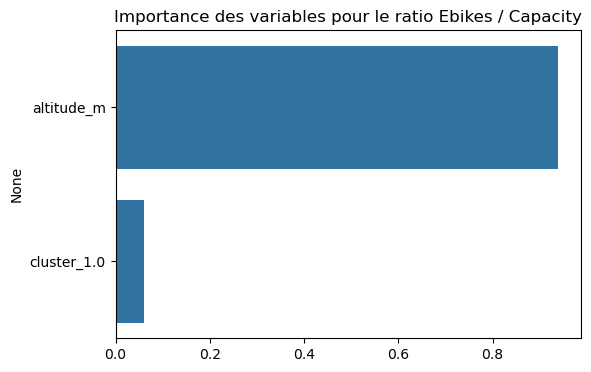

In [ ]:
# ----------------------------------------------------------
# Importance des variables avec Random Forest
# ----------------------------------------------------------
X = data[['altitude_m', 'cluster']]
y = data['ratio_ebikes']

# Encodage des clusters
X = pd.get_dummies(X, columns=['cluster'], drop_first=True)

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X, y)

print("\n====================")
print("Importance des variables (Random Forest)")
print("====================")
for name, imp in zip(X.columns, rf.feature_importances_):
    print(f" - {name} : {imp:.3f}")

plt.figure(figsize=(6,4))
sns.barplot(x=rf.feature_importances_, y=X.columns)
plt.title("Importance des variables pour le ratio Ebikes / Capacity")
plt.show()

In [132]:
corr = data["ratio_ebikes"].corr(data["altitude_m"])
print("Corrélation ratio_ebikes-altitude :", corr)

Corrélation ratio_ebikes-altitude : -0.028914697635158665


Ce score d'importance de 94 % pour l'altitude nous donne l'intuition que la variable altitude a une bien plus grande importance que la variable cluster sur le ratio de vélos électriques. Pour autant, cela peut être un biais. En effet, pour les random forest, il existe un biais de cardinalité assez classique. Selon ce biais, contrairement à la variable Cluster qui est binaire (0 ou 1) et ne permet qu'une seule division, l'altitude est une variable continue qui offre des centraines de seuils de coupure possibles. Cela va mathématiquement favoriser l'altitude lors de la construction des arbres.
De plus, il s'agit d'un score relatif : une fois le cluster défini, la rariable "Cluster" devient constante et inutile pour distinguer les stations entre elles. Le modèle se rabat alors mécaniquement sur l'altitude pour tenter d'expliquer les variations résiduelles ou le "bruit" statistique local. Ce résultat indique donc que l'altitude est la variable la plus mobilisée par l'algorithme pour micro-segmenter les données, mais ne prouve pas forcément qu'elle exerce un pouvoir explicatif fort.

en réalité un artefact technique classique des forêts aléatoires, connu sous le nom de biais de cardinalité. Contrairement à la variable "Cluster" qui est binaire (0 ou 1) et ne permet qu'une seule division, l'altitude est une variable continue offrant des centaines de seuils de coupure possibles, ce qui la favorise mathématiquement lors de la construction des arbres. De plus, ce score est relatif : une fois le cluster défini, la variable "Cluster" devient constante et inutile pour distinguer les stations entre elles ; le modèle se rabat alors mécaniquement sur l'altitude pour tenter d'expliquer les variations résiduelles ou le "bruit" statistique local. Ce résultat indique donc que l'altitude est la variable la plus mobilisée par l'algorithme pour micro-segmenter les données, mais ne prouve pas qu'elle exerce un pouvoir explicatif fort, surtout au regard de la faible performance prédictive globale du modèle.

# On fixe un cluster et on analyse la répartition de velibs électrique/capacité selon l'altitude

In [133]:
# ----------------------------------------------------------
# Analyse au sein d’un cluster
# ----------------------------------------------------------

# Exemple : cluster 0
data_cluster_0 = data[data['cluster'] == 0].copy()

# Standardisation des variables numériques pour le modèle
#scaler = StandardScaler()
#data_cluster[['altitude_m', 'ratio_ebikes']] = scaler.fit_transform(
    #data_cluster[['altitude_m', 'ratio_ebikes']]

In [134]:
# ----------------------------------------------------------
# Modèle mixte (effet aléatoire par station)
# ----------------------------------------------------------

print(len(data_cluster_0))
print(data_cluster_0["Code Station"].max())



model = smf.mixedlm(
    "ratio_ebikes ~ altitude_m + Timer",
    data=data_cluster_0,
    groups=data_cluster_0["Code Station"]
).fit(method='nm', maxiter=500, disp=False)


print("\n====================")
print(f"RÉSULTATS DU MODÈLE MIXTE pour le cluster 0")
print("====================")
print(model.summary())


330666
20006.0


/Users/paulemiletrancois/opt/anaconda3/envs/geo/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning:

The MLE may be on the boundary of the parameter space.




RÉSULTATS DU MODÈLE MIXTE pour le cluster 0
                        Mixed Linear Model Regression Results
Model:                     MixedLM          Dependent Variable:          ratio_ebikes
No. Observations:          330666           Method:                      REML        
No. Groups:                462              Scale:                       0.0139      
Min. group size:           387              Log-Likelihood:              233683.7104 
Max. group size:           720              Converged:                   Yes         
Mean group size:           715.7                                                     
-------------------------------------------------------------------------------------
                                          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------
Intercept                                  0.187    0.010  18.996 0.000  0.168  0.206
Timer[T.Timestamp('2025-11-13 16:

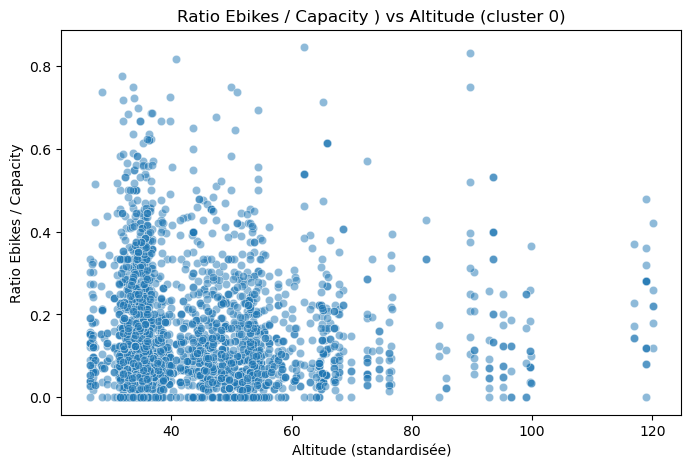

In [ ]:

# ----------------------------------------------------------
# Visualisation : ratio vs altitude
# ----------------------------------------------------------

# Scatterplot : ratio vs altitude
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=data_cluster_0.sample(min(3000, len(data_cluster_0))),
    x='altitude_m',
    y='ratio_ebikes',
    alpha=0.5
)
plt.title(f"Ratio Ebikes / Capacity vs Altitude (cluster 0)")
plt.xlabel("Altitude (standardisée)")
plt.ylabel("Ratio Ebikes / Capacity")
plt.show()


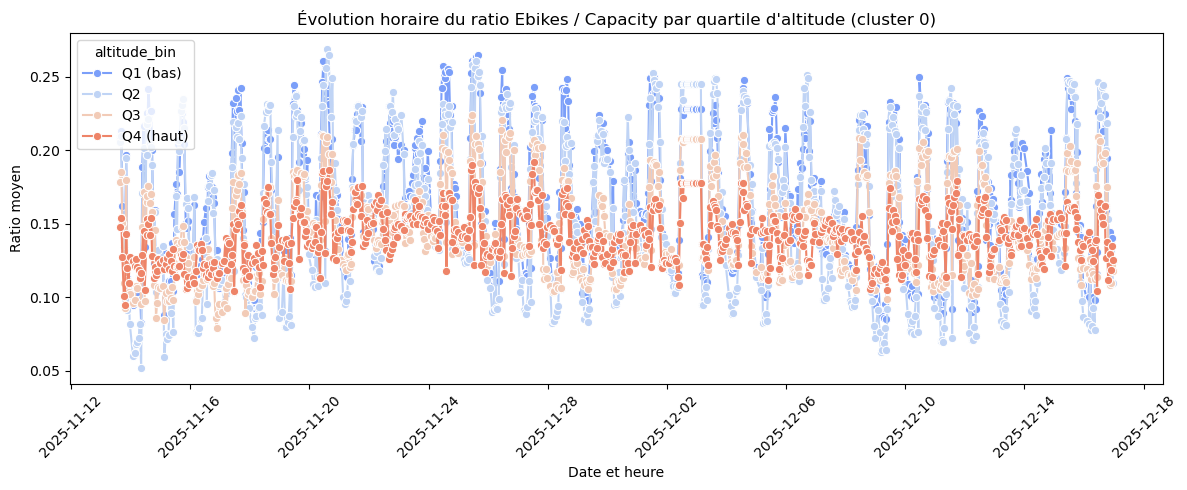

In [138]:
# ----------------------------------------------------------
# Évolution horaire du ratio selon quartiles d'altitude
# ----------------------------------------------------------

# Découpage de l'altitude en quartiles
data_cluster_0['altitude_bin'] = pd.qcut(data_cluster_0['altitude_m'], q=4, labels=['Q1 (bas)','Q2','Q3','Q4 (haut)'])

# Calcul de la moyenne log_ratio par Timer et altitude_bin
hourly_ratio = data_cluster_0.groupby(
    ['Timer','altitude_bin'], observed=True
).agg(
    mean_ratio=('ratio_ebikes','mean')
).reset_index()

# Figure
plt.figure(figsize=(12,5))
sns.lineplot(
    data=hourly_ratio,
    x='Timer',
    y='mean_ratio',
    hue='altitude_bin',
    marker='o',
    palette='coolwarm'
)

# Amélioration de l'axe des x
plt.title(f"Évolution horaire du ratio Ebikes / Capacity par quartile d'altitude (cluster 0)")
plt.xlabel("Date et heure")
plt.ylabel("Ratio moyen")

# Rotation des labels et espacement pour lisibilité
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))  # Affiche seulement 10 labels sur l'axe x

plt.tight_layout()
plt.show()


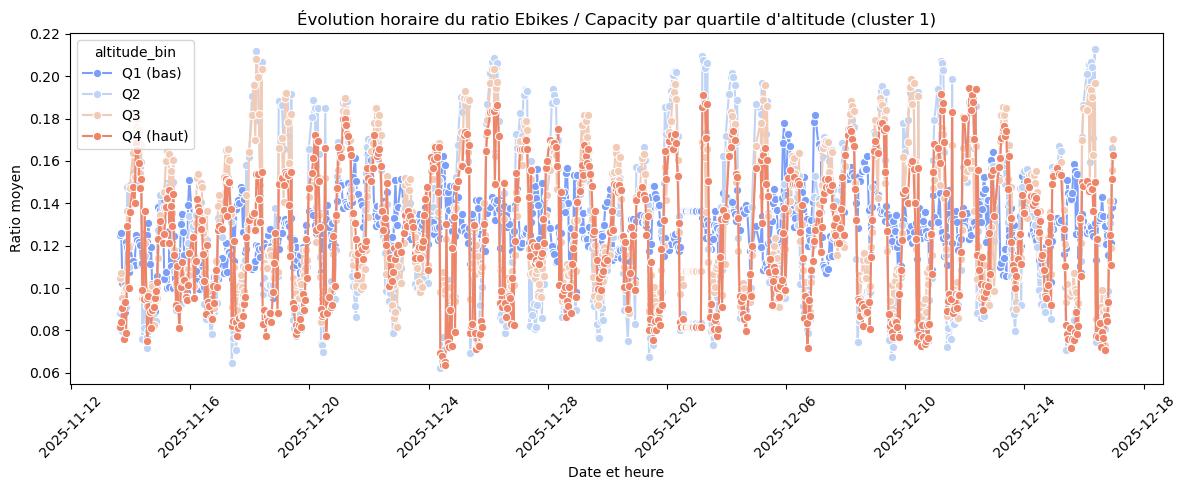

In [139]:
# On compare avec le cluster 1
data_cluster_1 = data[data['cluster'] == 1].copy()
# Découpage de l'altitude en quartiles
data_cluster_1['altitude_bin'] = pd.qcut(data_cluster_1['altitude_m'], q=4, labels=['Q1 (bas)','Q2','Q3','Q4 (haut)'])
# Calcul de la moyenne log_ratio par Timer et altitude_bin
hourly_ratio = data_cluster_1.groupby(
    ['Timer','altitude_bin'], observed=True
).agg(
    mean_ratio=('ratio_ebikes','mean')
).reset_index()
# Figure
plt.figure(figsize=(12,5))
sns.lineplot(
    data=hourly_ratio,
    x='Timer',
    y='mean_ratio',
    hue='altitude_bin',
    marker='o',
    palette='coolwarm'
)
# Amélioration de l'axe des x
plt.title(f"Évolution horaire du ratio Ebikes / Capacity par quartile d'altitude (cluster 1)")
plt.xlabel("Date et heure")
plt.ylabel("Ratio moyen")
# Rotation des labels et espacement pour lisibilité
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))  #Affiche seulement 10 labels sur l'axe x
plt.tight_layout()
plt.show()

In [140]:
data_cluster_0.groupby('altitude_bin')[['Ebikes','Mechanical Bikes', 'Capacity', 'ratio_ebikes']].mean()

/var/folders/m_/f0g35sbd4qq_ljpgtfb3dy4r0000gn/T/ipykernel_6790/2509916786.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,Ebikes,Mechanical Bikes,Capacity,ratio_ebikes
altitude_bin,,,,
Q1 (bas),4.719501,12.171175,31.075090,0.166159
Q2,4.865617,13.706915,32.884371,0.157425
Q3,4.884972,14.751742,36.307221,0.144479
Q4 (haut),4.931933,16.257978,37.785499,0.141904


In [141]:
data_cluster_1.groupby('altitude_bin')[['Ebikes','Mechanical Bikes','Capacity', 'ratio_ebikes']].mean()

/var/folders/m_/f0g35sbd4qq_ljpgtfb3dy4r0000gn/T/ipykernel_6790/3677261281.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,Ebikes,Mechanical Bikes,Capacity,ratio_ebikes
altitude_bin,,,,
Q1 (bas),4.245240,3.760179,34.243169,0.128550
Q2,3.787815,2.891124,31.450690,0.126037
Q3,3.842795,2.977912,31.801518,0.128974
Q4 (haut),4.035017,3.566530,33.993781,0.122999


# Evolution par heure pour le cluster 0

In [142]:
# ==========================================================
# Analyse de l'influence de l'altitude sur la répartition
# des vélos par heure, en séparant les stations en quartiles
# ==========================================================

# Extraction heure
data_cluster_0['hour'] = data_cluster_0['Timer'].dt.hour

# ----------------------------------------------------------
# Agrégation par heure et quartile
# ----------------------------------------------------------

hourly_stats = data_cluster_0.groupby(
    ['hour','altitude_bin'], observed=True
).agg(
    mean_ebikes=('Ebikes','mean'),
    mean_ratio_ebikes=('ratio_ebikes','mean')
).reset_index()
hourly_stats.head()


,hour,altitude_bin,mean_ebikes,mean_ratio_ebikes
0,1,Q1 (bas),3.720949,0.133036
1,1,Q2,3.695618,0.121801
2,1,Q3,4.056060,0.125231
3,1,Q4 (haut),4.583433,0.136519
4,2,Q1 (bas),4.425121,0.155265


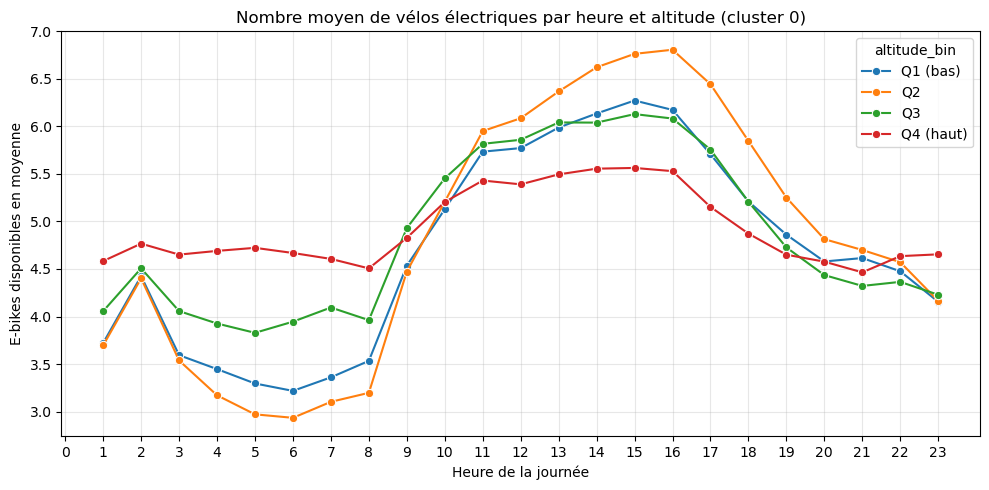

In [143]:
# ----------------------------------------------------------
# COURBE 1 – Nombre moyen d'Ebikes par heure pour le cluster 0
# ----------------------------------------------------------

plt.figure(figsize=(10,5))
sns.lineplot(
    data=hourly_stats,
    x='hour',
    y='mean_ebikes',
    hue='altitude_bin',
    marker='o'
)
plt.title("Nombre moyen de vélos électriques par heure et altitude (cluster 0)")
plt.xlabel("Heure de la journée")
plt.ylabel("E-bikes disponibles en moyenne")
plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

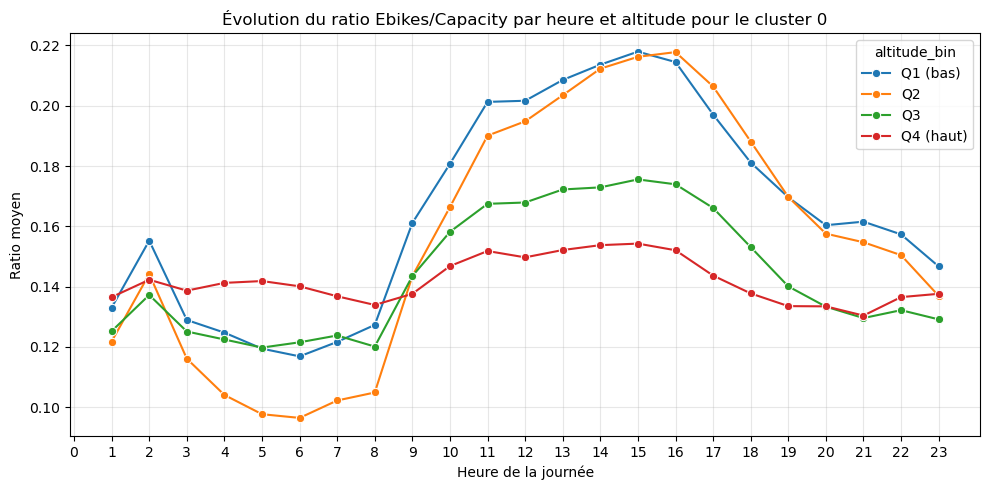

In [144]:
# ----------------------------------------------------------
# COURBE 2 – Évolution du ratio Ebikes/Capacity par heure pour le cluster 0
# ----------------------------------------------------------

plt.figure(figsize=(10,5))
sns.lineplot(
    data=hourly_stats,
    x='hour',
    y='mean_ratio_ebikes',
    hue='altitude_bin',
    marker='o'
)
plt.title("Évolution du ratio Ebikes/Capacity par heure et altitude pour le cluster 0")
plt.xlabel("Heure de la journée")
plt.ylabel("Ratio moyen")
plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Evolution du ratio par heure et altitude pour le cluster 1

In [145]:
# ==========================================================
# Analyse de l'influence de l'altitude sur la répartition
# des vélos par heure, en séparant les stations en quartiles
# ==========================================================

# Extraction heure
data_cluster_1['hour'] = data_cluster_1['Timer'].dt.hour

# ----------------------------------------------------------
# Agrégation par heure et quartile
# ----------------------------------------------------------

hourly_stats = data_cluster_1.groupby(
    ['hour','altitude_bin'], observed=True
).agg(
    mean_ebikes=('Ebikes','mean'),
    mean_ratio_ebikes=('ratio_ebikes','mean')
).reset_index()
hourly_stats.head()


,hour,altitude_bin,mean_ebikes,mean_ratio_ebikes
0,1,Q1 (bas),4.375641,0.134691
1,1,Q2,4.920369,0.162865
2,1,Q3,4.566975,0.156044
3,1,Q4 (haut),4.870990,0.149893
4,2,Q1 (bas),4.621757,0.141377


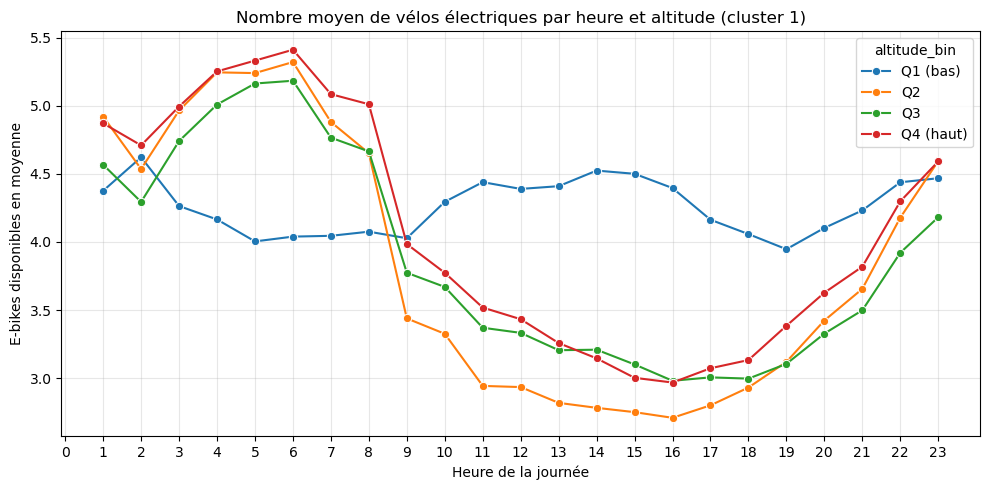

In [146]:
# ----------------------------------------------------------
# COURBE 1 – Nombre moyen d'Ebikes par heure pour le cluster 1
# ----------------------------------------------------------

plt.figure(figsize=(10,5))
sns.lineplot(
    data=hourly_stats,
    x='hour',
    y='mean_ebikes',
    hue='altitude_bin',
    marker='o'
)
plt.title("Nombre moyen de vélos électriques par heure et altitude (cluster 1)")
plt.xlabel("Heure de la journée")
plt.ylabel("E-bikes disponibles en moyenne")
plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

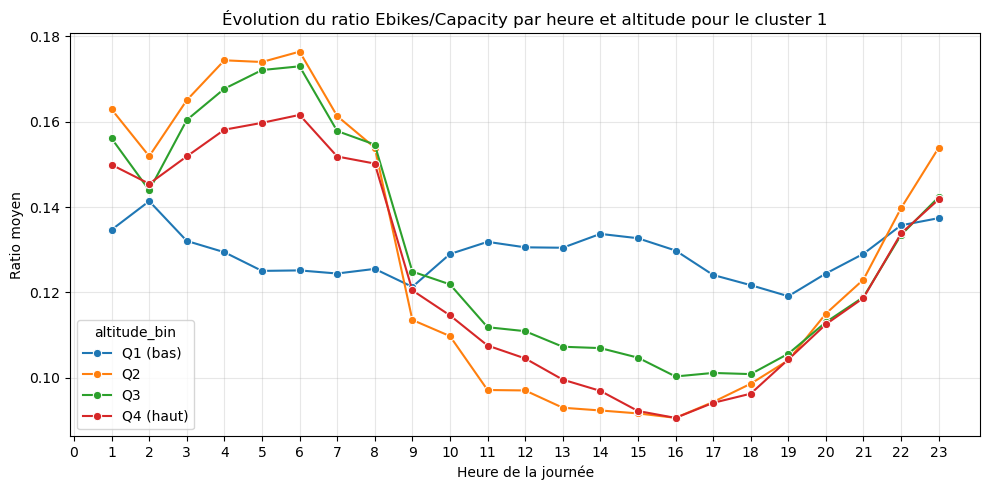

In [147]:
# ----------------------------------------------------------
# COURBE 2 – Évolution du ratio Ebikes/Capacity par heure pour le cluster 1
# ----------------------------------------------------------

plt.figure(figsize=(10,5))
sns.lineplot(
    data=hourly_stats,
    x='hour',
    y='mean_ratio_ebikes',
    hue='altitude_bin',
    marker='o'
)
plt.title("Évolution du ratio Ebikes/Capacity par heure et altitude pour le cluster 1")
plt.xlabel("Heure de la journée")
plt.ylabel("Ratio moyen")
plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [148]:
data_cluster_1.head()

,Code Station,cluster,altitude_m,Timer,Ebikes,Mechanical Bikes,Capacity,ratio_ebikes,altitude_bin,hour
0,16107.0,1.0,30.141733,2025-11-13 15:25:29,4.0,2.0,35.0,0.114286,Q1 (bas),15
1,11104.0,1.0,85.734704,2025-11-13 15:25:29,3.0,2.0,20.0,0.150000,Q4 (haut),15
4,15047.0,1.0,35.770282,2025-11-13 15:25:29,2.0,1.0,52.0,0.038462,Q1 (bas),15
7,5016.0,1.0,35.005961,2025-11-13 15:25:29,10.0,0.0,17.0,0.588235,Q1 (bas),15
10,17044.0,1.0,76.262679,2025-11-13 15:25:29,3.0,1.0,42.0,0.071429,Q4 (haut),15


# On tente une nouvelle analyse. On va caluler le ratio ebikes mais PAR RAPPORT aux mécaniques

Pour évaluer correctement la part de l'électrique sans introduire de biais statistique, nous avons opté pour une approche par agrégation spatiale plutôt que par moyenne arithmétique. Calculer un ratio station par station pose problème lorsque les stations sont vides (division par zéro) ou lorsqu'elles contiennent très peu de vélos (une station avec 1 seul vélo électrique affiche 100%, pesant autant qu'une station majeure). En sommant les vélos électriques et mécaniques par groupe d'altitude et par heure avant de calculer le ratio, nous obtenons une vision "macro" du parc disponible. Cela revient à considérer l'ensemble des stations d'une même tranche d'altitude comme une unique "super-station", ce qui lisse les anomalies locales et reflète fidèlement la probabilité réelle pour un usager de trouver un type de vélo spécifique dans la zone.

In [149]:
# %%
# ==========================================================
# 1. Calcul des agrégats pour éviter les divisions par zéro
# ==========================================================

def prepare_weighted_analysis(df, cluster_name):
    # 1. Création des quartiles d'altitude propres à ce cluster
    # On utilise qcut pour avoir 4 groupes de taille égale
    df = df.copy()
    df['altitude_bin'] = pd.qcut(df['altitude_m'], q=4, labels=['Q1 (Bas)', 'Q2', 'Q3', 'Q4 (Haut)'])
    
    # 2. On extrait l'heure si ce n'est pas déjà fait
    if 'hour' not in df.columns:
        df['hour'] = df['Timer'].dt.hour
        
    # 3. AGRÉGATION : On somme les vélos par Heure et Altitude
    # C'est ici qu'on règle le problème des stations vides. 
    # On regarde le stock TOTAL du groupe.
    agg = df.groupby(['hour', 'altitude_bin'], observed=True).agg({
        'Ebikes': 'sum',
        'Mechanical Bikes': 'sum'
    }).reset_index()
    
    # 4. Calcul du ratio sur les totaux
    agg['total_bikes'] = agg['Ebikes'] + agg['Mechanical Bikes']
    
    # Part de l'électrique = Somme Ebikes / Somme Totale
    agg['share_ebikes'] = agg['Ebikes'] / agg['total_bikes']
    
    agg['cluster_name'] = cluster_name
    return agg

In [150]:
# Application aux deux clusters
agg_cluster_0 = prepare_weighted_analysis(data_cluster_0, "Cluster 0 (Centre)")
agg_cluster_1 = prepare_weighted_analysis(data_cluster_1, "Cluster 1 (Résidentiel)")

print("Aperçu des données agrégées (Cluster 1) :")
print(agg_cluster_1.head())

Aperçu des données agrégées (Cluster 1) :
   hour altitude_bin   Ebikes  Mechanical Bikes  total_bikes  share_ebikes  \
0     1     Q1 (Bas)  12790.0           11535.0      24325.0      0.525797   
1     1           Q2  14397.0           10330.0      24727.0      0.582238   
2     1           Q3  13331.0            9352.0      22683.0      0.587709   
3     1    Q4 (Haut)  14121.0           11797.0      25918.0      0.544834   
4     2     Q1 (Bas)   5523.0            4328.0       9851.0      0.560654   

              cluster_name  
0  Cluster 1 (Résidentiel)  
1  Cluster 1 (Résidentiel)  
2  Cluster 1 (Résidentiel)  
3  Cluster 1 (Résidentiel)  
4  Cluster 1 (Résidentiel)  


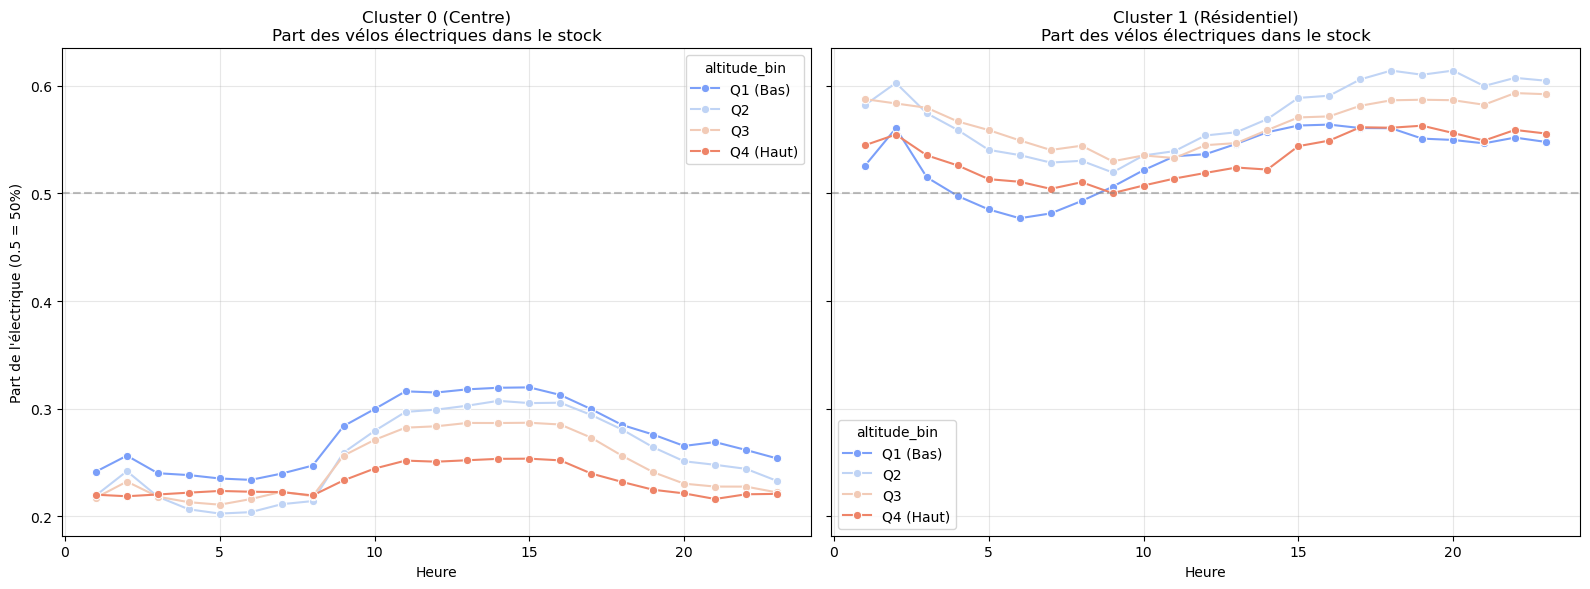

In [151]:
# %%
# ==========================================================
# 2. Visualisation : La domination de l'électrique en altitude ?
# ==========================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# --- Graphique Cluster 0 (Centre) ---
sns.lineplot(
    data=agg_cluster_0,
    x='hour',
    y='share_ebikes',
    hue='altitude_bin',
    palette='coolwarm', # Bleu = Bas, Rouge = Haut
    marker='o',
    ax=axes[0]
)
axes[0].set_title("Cluster 0 (Centre)\nPart des vélos électriques dans le stock")
axes[0].set_ylabel("Part de l'électrique (0.5 = 50%)")
axes[0].set_xlabel("Heure")
axes[0].grid(True, alpha=0.3)
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5) # Ligne d'équilibre

# --- Graphique Cluster 1 (Résidentiel) ---
sns.lineplot(
    data=agg_cluster_1,
    x='hour',
    y='share_ebikes',
    hue='altitude_bin',
    palette='coolwarm',
    marker='o',
    ax=axes[1]
)
axes[1].set_title("Cluster 1 (Résidentiel)\nPart des vélos électriques dans le stock")
axes[1].set_xlabel("Heure")
axes[1].grid(True, alpha=0.3)
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Le graphique de gauche pour le cluster 0 confirme parfaitement notre hypothèse de contrôle.

Observation : Les courbes Q1, Q2, Q3 et Q4 sont écrasées les unes sur les autres et restent basses (autour de 20-30% de part d'électrique).

Interprétation : Dans le centre de Paris, l'altitude n'a aucun effet discriminant. Le relief est trop faible et la rotation des vélos trop rapide pour qu'un tri s'opère. C'est un système "liquide" et homogène.

Pour le coeur de l'analyse, le cluster 1, on observe des résultats surprenant.
La courbe bleue (Q1 - Bas) est la plupart du temps la plus basse (environ 45-50% d'électrique), sauf en journée (mmoment où le cluster 1 se vide)
Par contre étonnemment ce sont les courbes Q2 et Q3 les plus élevées, avec une part des vélos électriques en permanence autour de 50-60%. Les zones les plus "électrifiées" semblent donc être les zones intermédiaires.
La courbe rouge (les plus hautes stations) n'est pas la plus haute. Elle commence même assez bas le matin.

La conclusion la plus probable au regard de toutes ces analyses et résultats est que l'altitude n'a pas d'effet sur la répartition des vélibs au sein des clusters. Néanmoins, il est possible de constater que ce ratio de vélibs électriques est toujours plus élevée dans les zones résidentielles que centrales.

Hypothèse, cela s'explique peut être par la taille des trajets ? Possible voie à étudier.